# 1. Libraries

In [1]:
# LabOne Q:
from laboneq.simple import *

# User libraries:
from lib.helpers.example_notebook_helper import *
from lib.helpers.meas_helper_mod import *
from lib.helpers.setup_helper import *
from lib.helpers.save_data_helper import *
from lib.helpers.create_meas_helper import *
# from lib.helpers.pop_temp_helper import *
from lib.helpers.pop_temp_helper_v2 import *
from lib.helpers.fitting_helper import *
import lib.utils.calculator as calc

# Python libraries:
from scipy.io import savemat, loadmat
from scipy.stats import norm
from scipy.optimize import curve_fit
from scipy import fft
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os.path
import time
import json as js
from scresonators import fit_single_STS_wrapper, plot_single_STS_wrapper
import pyvisa

# Instruments:
from blueftc.BlueforsController import BlueFTController
from lib.devices.bftc_credentials import BFTS_API_KEY, BFTS_IP, PORT_NUMBER, MXC_ID
from lib.devices.KeysightDMM34465A import KeysightDMM34465A
from lib.devices.SIM_wrapper import SIM900, SIM928
from lib.devices.YokoGS200_wrapper import YokoGS200

# XLD server measurements:
from lib.devices.XLD_Server_Client import XLDMeasClient
from time import sleep
from lib.devices.XLD_Server_Passkey import xld_ip

# Quantum object management:
from qmeas.qsample import QSample
from qmeas.qparameters import QBaseParameters, QLinkedParameters

In [2]:
import os
import sounddevice as sd
import soundfile as sf
from pprint import pprint

mute = False

def meas_ready():
    global mute 
    
    if not mute:
        path = os.path.join("lib", "utils", "ding.mp3")
        try:
            data, samplerate = sf.read(path)
            sd.play(data, samplerate)
            sd.wait()
        except Exception as e:
            print(f"meas_ready: audio playback unavailable: {e}")
            mute = True

# 2. Device Setup

## 2.1. Temperature Controller

In [ ]:
#Temperature controller parameters

import requests
from requests.packages.urllib3.exceptions import InsecureRequestWarning

requests.packages.urllib3.disable_warnings(InsecureRequestWarning)

BFTCont = BlueFTController(ip=BFTS_IP, port=PORT_NUMBER, key=BFTS_API_KEY, 
                              mixing_chamber_channel_id=MXC_ID)

BFTCont.get_mxc_temperature()

## 2.2. Voltage Source 
HERE FLUX FIXED AT $-1.2\text{V}$ VIA $5.6k\Omega$

In [ ]:
#Volt source parameters
Yoko_addr = 'TCPIP0::192.168.1.201::inst0::INSTR'
volt_source = YokoGS200(address=Yoko_addr)
R = 5.4e3 #Ohm

In [ ]:
volt_source.set_range(10)
volt_source.get_range()

## 2.3. Sample Parameters

In [3]:
cooldown_nr = 2

In [4]:
#dictionary for sample parameters
sample_parameters = {
    'folder_name': r'N:\xld\Kubatkin\Data',
    'sample_name': r'S3',
    'structure_name': 'Q2'
}

qsample_params = QSample(directory=sample_parameters['folder_name'], 
                         sample=sample_parameters['sample_name'], 
                         structure=sample_parameters['structure_name'])

### Qubit and LO parameters

#### A: New parameters

In [5]:
# a collection of qubit control and readout parameters as a python dictionary
qubit_parameters = {
    'ro_freq'       : 136e6,        # readout frequency of qubit 0 in [Hz] - relative to local oscillator for readout drive upconversion
    'ro_amp'        : 0.5,          # readout amplitude
    'ro_amp_spec'   : 0.05,         # readout amplitude for spectroscopy 0.05
    'ro_len'        : 2.0e-6,       # readout pulse length in [s]
    'ro_len_spec'   : 4.0e-6,       # readout pulse length for resonator spectroscopy in [s]
    'ro_delay'      : 0.0,          # readout delay after last drive signal in [s]
    'ro_int_delay'  : 330e-9,       # readout line offset calibration - delay between readout pulse and start of signal acquisition in [s]
    
    'th_res_freq'   : 0.0,
    
    'qb_freq'       : 50e6,         # qubit 0 drive frequency in [Hz] - relative to local oscillator for qubit drive upconversion
    'qb_anharm'     : 200e6,
    'qb_amp_spec'   : 0.0001,       # drive amplitude of qubit spectroscopy
    'qb_len_spec'   : 15e-6,        # drive pulse length for qubit spectroscopy in [s]
    'qb_len'        : 6e-8,         # qubit drive pulse length in [s]
    'pi_amp'        : 1.0,          # qubit drive amplitude for pi pulse
    'pi_half_amp'   : 0.25,         # qubit drive amplitude for pi/2 pulse
    'qb_t1'         : 6e-6,         # qubit T1 time
    'qb_t2_ramsey'  : 1e-6,         # qubit T2 time
    'ramsey_det'    : 2e6,          # qubit frequency detuning relative to qb_freq in [Hz]
    'qb_t2_echo'    : 1e-6,         # qubit T2 time
    'relax'         : 500e-6        # delay time after each measurement for qubit reset in [s]
}

qubit_parameters = QBaseParameters(sample=qsample_params,
                                    name=f'qubit_parameters_cooldown_{cooldown_nr}',
                                    parameters=qubit_parameters)

In [6]:
# up / downconversion settings - to convert between IF and RF frequencies 
# steps of 200Mh
lo_settings = {
    'qb_lo'         : 3.8e9,        # qubit LO frequency in [Hz]
    'ro_lo'         : 6.2e9         # R1 readout LO frequency in [Hz]
}

lo_settings = QBaseParameters(sample=qsample_params,
                             name=f'lo_settings_cooldown_{cooldown_nr}',
                             parameters=lo_settings)

#### B: Load parameters from file

In [ ]:
previous_cooldown = 1

root_dir = os.path.join(sample_parameters['folder_name'], sample_parameters['sample_name'], sample_parameters['structure_name'], 'parameters')

with open(os.path.join(root_dir, f'lo_settings_cooldown_{previous_cooldown}.txt'), 'r') as f:
    pars = js.load(f)

    lo_settings = QBaseParameters(sample=qsample_params,
                            name=f'lo_settings_cooldown_{cooldown_nr}',
                            parameters=pars)

with open(os.path.join(root_dir, f'qubit_parameters_cooldown_{previous_cooldown}.txt'), 'r') as f:
    pars = js.load(f)

    qubit_parameters = QBaseParameters(sample=qsample_params,
                            name=f'qubit_parameters_cooldown_{cooldown_nr}',
                            parameters=pars)

## 2.4. Zurich Instruments SFHQC

In [7]:
# define the DeviceSetup from descriptor - additionally include information on the dataserver used to connect to the instruments 
my_setup = DeviceSetup.from_descriptor(
    my_descriptor,
    server_host="localhost",
    server_port="8004",
    setup_name="XLD",
) 

### Create and Connect to a LabOne Q Session

In [8]:
# define Calibration object based on qubit control and readout parameters
my_calibration = define_calibration(parameters=qubit_parameters, lo_settings=lo_settings)

# apply calibration to device setup
my_setup.set_calibration(my_calibration)

In [9]:
## define shortcut to logical signals for convenience
lsg_q0                  = my_setup.logical_signal_groups["q0"].logical_signals

drive_Oscillator_q0     = lsg_q0["drive"].oscillator
drive_ef_Oscillator_q0  = lsg_q0["drive_ef"].oscillator
readout_Oscillator_q0   = lsg_q0["measure"].oscillator
acquire_Oscillator_q0   = lsg_q0["acquire"].oscillator

In [10]:
lsg_q0["acquire"].port_delay
lsg_q0["acquire"].range = -35

### Emulation Option

In [11]:
# perform experiments in emulation mode only? - if True, also generate dummy data for fitting
emulate = True

# create and connect to a session
my_session = Session(device_setup=my_setup)
my_session.connect(do_emulation=emulate, ignore_version_mismatch = True)

[2026.07.09 17:01:30.951] INFO    Logging initialized from [Default inline config in laboneq.laboneq_logging] logdir is /Users/khatran/Desktop/superconducting-qubit-thermometry/laboneq_output/log
[2026.07.09 17:01:30.953] INFO    VERSION: laboneq 26.4.0
[2026.07.09 17:01:30.954] INFO    Connecting to data server at localhost:8004
[2026.07.09 17:01:30.955] INFO    Connected to Zurich Instruments LabOne Data Server version 26.04.1.6 at localhost:8004
[2026.07.09 17:01:30.957] INFO    Configuring the device setup
[2026.07.09 17:01:30.962] INFO    The device setup is configured


In [12]:
#Check ranges
print('Drive line range:'  , lsg_q0["drive"].range  , 'dBm')
print('Measure line range:', lsg_q0["measure"].range, 'dBm')
print('Acquire line range:', lsg_q0["acquire"].range, 'dBm')

Drive line range: 5 dBm
Measure line range: -25 dBm
Acquire line range: -35 dBm


# 3. Spectroscopy

## 3.1. Pulsed Resonator Spectroscopy

### 3.1.1. Prepare Experiment

In [13]:
# frequency range of spectroscopy scan -
# around expected centre frequency as defined in qubit parameters
spec_range = 10e6
start_freq = qubit_parameters["ro_freq"] - spec_range / 2
stop_freq = qubit_parameters["ro_freq"] + spec_range / 2
num_points = 51


# define sweep parameter
def create_readout_freq_sweep(qubit, start_freq, stop_freq, num_points):
    return LinearSweepParameter(
        uid=f"{qubit}_res_freq",
        start=start_freq,
        stop=stop_freq,
        count=num_points,
        axis_name="Frequency [Hz]",
    )


# define number of averages
# used for 2^num_averages, maximum: num_averages = 17
num_averages = 13

# readout pulse parameters and definition
envelope_duration = qubit_parameters["ro_len_spec"]
envelope_rise_fall_time = 0.05e-6
readout_pulse = pulse_library.const(
    uid="readout_pulse", length=envelope_duration, amplitude=qubit_parameters["ro_amp_spec"]
)

In [14]:
# function that defines a resonator spectroscopy experiment, and takes the frequency sweep as a parameter


def res_spectroscopy_pulsed(freq_sweep, num_averages, readout_pulse):
    # Create resonator spectroscopy experiment - uses only readout drive and signal acquisition
    exp_spec_pulsed = Experiment(
        uid="Resonator Spectroscopy",
        signals=[
            ExperimentSignal("measure"),
            ExperimentSignal("acquire"),
        ],
    )

    ## define experimental sequence
    # outer loop - vary drive frequency

    # inner loop - average multiple measurements for each frequency - measurement in spectroscopy mode
    with exp_spec_pulsed.acquire_loop_rt(
        uid="shots",
        count=2**num_averages,
        acquisition_type=AcquisitionType.SPECTROSCOPY,
        averaging_mode=AveragingMode.SEQUENTIAL,
    ):
        with exp_spec_pulsed.sweep(uid="res_freq", parameter=freq_sweep):
            # readout pulse and data acquisition
            with exp_spec_pulsed.section(uid="spectroscopy"):
                # play resonator excitation pulse
                exp_spec_pulsed.play(signal="measure", pulse=readout_pulse)
                # resonator signal readout
                exp_spec_pulsed.acquire(
                    signal="acquire", handle="res_spec_pulsed", length=envelope_duration
                )
            # relax time after readout - for signal processing and qubit relaxation to ground state
            with exp_spec_pulsed.section(uid="relax", length=1e-6):
                exp_spec_pulsed.reserve(signal="measure")

    return exp_spec_pulsed

In [15]:
def res_spec_calib(freq_sweep):
    exp_calibration = Calibration()
    # sets the oscillator of the experimental measure signal
    # for spectroscopy, set the sweep parameter as frequency
    measure_acquire_oscillator = Oscillator(
        "readout_osc",
        frequency=freq_sweep,
        modulation_type=ModulationType.HARDWARE
    )
    exp_calibration["measure"] = SignalCalibration(
        oscillator=measure_acquire_oscillator
    )
    exp_calibration["acquire"] = SignalCalibration(
        oscillator=measure_acquire_oscillator
    )
    return exp_calibration


# signal maps for the two different qubits - maps the logical signal of the device setup to the experimental signals of the experiment


def res_spec_map(qubit):
    signal_map = {
        "measure": my_setup.logical_signal_groups[f"{qubit}"].logical_signals[
            "measure"
        ],
        "acquire": my_setup.logical_signal_groups[f"{qubit}"].logical_signals[
            "acquire"
        ],
    }
    return signal_map

### 3.1.2. Compile & Run

In [16]:
freq_sweep = create_readout_freq_sweep("q0", start_freq, stop_freq, num_points)

# define the experiment with the frequency sweep relevant for qubit 0
exp_spec_pulsed = res_spectroscopy_pulsed(freq_sweep, num_averages, readout_pulse)

# set signal calibration and signal map for experiment to qubit 0
exp_spec_pulsed.set_calibration(res_spec_calib(freq_sweep))
exp_spec_pulsed.set_signal_map(res_spec_map("q0"))

In [17]:
# compile the experiment on the open instrument session
compiled_spec_pulsed = my_session.compile(exp_spec_pulsed)

[2026.07.09 17:01:36.615] INFO    Starting LabOne Q Compiler run...
[2026.07.09 17:01:36.617] INFO    Schedule completed. [0.000 s]
[2026.07.09 17:01:36.623] INFO    Code generation completed for all AWGs. [0.006 s]
[2026.07.09 17:01:36.624] INFO    Completed compilation step 1 of 1. [0.007 s]
[2026.07.09 17:01:36.630] INFO     ────────────────────────────────────────────────────────────────── 
[2026.07.09 17:01:36.630] INFO      Device         AWG   SeqC LOC   CT entries   Waveforms   Samples  
[2026.07.09 17:01:36.630] INFO     ────────────────────────────────────────────────────────────────── 
[2026.07.09 17:01:36.630] INFO      device_shfqc     0         23            0           1     16000  
[2026.07.09 17:01:36.631] INFO     ────────────────────────────────────────────────────────────────── 
[2026.07.09 17:01:36.631] INFO      TOTAL                      23            0                 16000  
[2026.07.09 17:01:36.631] INFO     ────────────────────────────────────────────────────

In [18]:
# run the experiment on the open instrument session
spec_pulse_results = my_session.run(compiled_spec_pulsed)

meas_ready()

[2026.07.09 17:01:37.487] INFO    Starting near-time execution...
[2026.07.09 17:01:37.501] INFO    Finished near-time execution.


### 3.1.3. Analysis

In [20]:
# get the measurement data returned by the instruments from the LabOne Q session
spec_res = spec_pulse_results.get_data("res_spec_pulsed")

# define the frequency axis from the qubit parameters
spec_freq = lo_settings["ro_lo"] + spec_pulse_results.get_axis("res_spec_pulsed")[0]

INFO: *STS Fitter* loaded data from 1 measurements.
INFO: temperatures (mK): [0]
INFO:  (): [0]
INFO: *STS Fitter* started fitting resonance curves.
INFO: *STS Fitter* is done!
{'f0': np.float64(6325442103.117707), 'f0_sigma': np.float64(2.8508058603171346e-09), 'qc': np.float64(32654366.008464083), 'qc_sigma': np.float64(5.028477951808649e-10), 'qi': np.float64(791.9512317407674), 'qi_sigma': np.float64(0.0006830779598710199)}
RO Frequency: 125.44210311770725 MHz


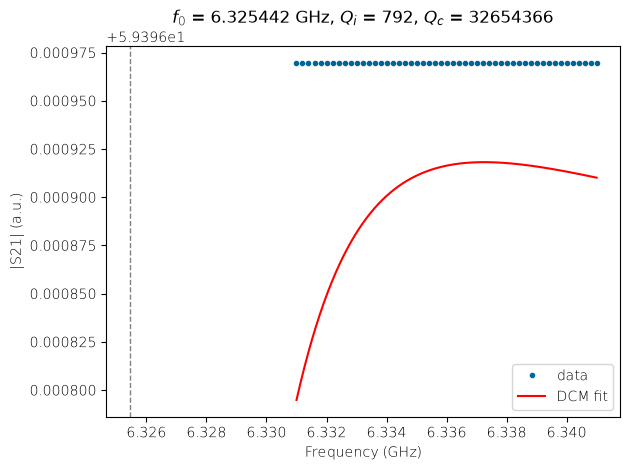

In [21]:
# fit to asymmetric Lorentzian model 
full_result, quick_result, sweep_manager = fit_single_STS_wrapper(freqs=spec_freq, y_data=spec_res)
print(quick_result)

fig, ax = plot_single_STS_wrapper(sweep_man=sweep_manager)

#Change RO freq
qubit_parameters.update_parameter("ro_freq", quick_result['f0'] - lo_settings["ro_lo"])
print('RO Frequency:', qubit_parameters["ro_freq"] * 1e-6, 'MHz')

In [22]:
print('Readout frequency from fit: ', qubit_parameters["ro_freq"]*1e-6, 'MHz')

Readout frequency from fit:  125.44210311770725 MHz


## 3.2. Pulsed Qubit Spectroscopy

### 3.2.1. Pulsed Measurements Presettings

In [23]:
# manual settings of the readout and exitation pulse properties

# exitation:
qubit_parameters.update_parameter("qb_len_spec", 20e-6)
qubit_parameters.update_parameter("qb_amp_spec", 0.6)

print('Qubit spectroscopy length:', qubit_parameters["qb_len_spec"] * 1e6, 'mks')
print('Qubit spectroscopy amplitude:', qubit_parameters["qb_amp_spec"])

# readout:
# qubit_parameters["ro_len"] = 2e-6 
# qubit_parameters["ro_amp"] = 0.2

print('Readout length:', qubit_parameters["ro_len"] * 1e6, 'mks')
print('Readout amplitude:', qubit_parameters["ro_amp"])

# relaxation:
# qubit_parameters.update_parameter('relax', 75e-6)
print('Relaxation time:', qubit_parameters['relax'] * 1e6, 'mks')

Qubit spectroscopy length: 20.0 mks
Qubit spectroscopy amplitude: 0.6
Readout length: 2.0 mks
Readout amplitude: 0.5
Relaxation time: 500.0 mks


In [24]:
# pulse settings

# qubit excite pulse
square_pulse = pulse_library.gaussian(
    uid="const_gauss",
    length=qubit_parameters["qb_len_spec"],
    amplitude=qubit_parameters["qb_amp_spec"],
)

# qubit readout pulse - here simple constant pulse
readout_pulse = pulse_library.const(
    uid="readout_pulse",
    length=qubit_parameters["ro_len"],
    amplitude=qubit_parameters["ro_amp"],
)
# integration weights for qubit measurement - here simple constant weights, i.e. all parts of the return signal are weighted equally
readout_weighting_function = pulse_library.const(
    uid="readout_weighting_function", length=qubit_parameters["ro_len"], amplitude=1.0
)

In [25]:
readout_spec = {
    'readout_type'              : 'spectroscopy',
    'readout_pulse'             : readout_pulse,
    'readout_weighting_function': readout_weighting_function,
    'relax_time'                : qubit_parameters["relax"],
    'measure_freq'              : qubit_parameters["ro_freq"],
    'acquire_freq'              : qubit_parameters["ro_freq"],
    'readout_range'             : -25,
    'readout_delay'             : qubit_parameters['ro_int_delay']
}

In [26]:
print('Qubit frequency before spectroscopy:', qubit_parameters["qb_freq"] * 1e-6, 'MHz')

Qubit frequency before spectroscopy: 50.0 MHz


### 3.2.2. Prepare Experiment

In [27]:
# define number of averages
# used for 2^num_averages, maximum: num_averages = 17
num_averages = 12

# pulse parameters and definitions
envelope_duration = qubit_parameters["ro_len"]


def create_readout_pulse(
    qubit, length=envelope_duration, amplitude=qubit_parameters["ro_amp"]
):
    readout_pulse = pulse_library.gaussian_square(
        uid=f"readout_pulse_{qubit}",
        length=length,
        amplitude=amplitude,
    )
    return readout_pulse


drive_length = qubit_parameters["qb_len_spec"]


def create_drive_spec_pulse(qubit, length=drive_length, amplitude=qubit_parameters["qb_amp_spec"]):
    pulse = pulse_library.const(
        uid=f"drive_spec_pulse_{qubit}", length=length, amplitude=amplitude
    )
    return pulse


def create_drive_freq_sweep(qubit, start_freq, stop_freq, num_points):
    return LinearSweepParameter(
        uid=f"drive_freq_{qubit}", start=start_freq, stop=stop_freq, count=num_points
    )

In [28]:
# function that returns a qubit spectroscopy experiment- accepts frequency sweep range as parameter


def qubit_spectroscopy(freq_sweep, drive_pulse, readout_pulse, num_averages):
    # Create qubit spectroscopy Experiment - uses qubit drive, readout drive and data acquisition lines
    exp_qspec = Experiment(
        uid="Qubit Spectroscopy",
        signals=[
            ExperimentSignal("drive"),
            ExperimentSignal("measure"),
            ExperimentSignal("acquire"),
        ],
    )

    # inner loop - real-time averaging - QA in integration mode
    with exp_qspec.acquire_loop_rt(
        uid="freq_shots",
        count=2**num_averages,
        acquisition_type=AcquisitionType.INTEGRATION,
    ):
        with exp_qspec.sweep(uid="qfreq_sweep", parameter=freq_sweep):
            # qubit drive
            with exp_qspec.section(uid="qubit_excitation"):
                exp_qspec.play(signal="drive", pulse=drive_pulse)
            with exp_qspec.section(
                uid="readout_section", play_after="qubit_excitation"
            ):
                # play readout pulse on measure line
                exp_qspec.play(signal="measure", pulse=readout_pulse)
                # trigger signal data acquisition
                exp_qspec.acquire(
                    signal="acquire",
                    handle="qb_spec",
                    kernel=readout_pulse,
                )
            # relax time after readout - for qubit relaxation to groundstate and signal processing
            with exp_qspec.section(uid="relax", length=1e-6):
                exp_qspec.reserve(signal="measure")

    return exp_qspec

In [29]:
# frequency range of spectroscopy scan - defined around expected qubit frequency as defined in qubit parameters
qspec_range = 10e6
start_freq = qubit_parameters["qb_freq"] - qspec_range / 2
stop_freq = qubit_parameters["qb_freq"] + qspec_range / 2
# how many frequency points to measure
qspec_num = 101

freq_sweep_q0 = create_drive_freq_sweep("q0", start_freq, stop_freq, qspec_num)

# experiment signal calibration for qubit 0
exp_calibration_q0 = Calibration()
exp_calibration_q0["drive"] = SignalCalibration(
    oscillator=Oscillator(
        frequency=freq_sweep_q0,
        modulation_type=ModulationType.HARDWARE,
    ),
)


# signal map for qubit 0
def signal_map_default(qubit):
    signal_map = {
        "drive": my_setup.logical_signal_groups[f"{qubit}"].logical_signals[
            "drive"
        ],
        "measure": my_setup.logical_signal_groups[f"{qubit}"].logical_signals[
            "measure"
        ],
        "acquire": my_setup.logical_signal_groups[f"{qubit}"].logical_signals[
            "acquire"
        ],
    }
    return signal_map


# define experiment with frequency sweep for qubit 0
drive_pulse = create_drive_spec_pulse("q0")
readout_pulse = create_readout_pulse("q0")

exp_qspec = qubit_spectroscopy(freq_sweep_q0, drive_pulse, readout_pulse, num_averages)

# apply calibration and signal map for qubit 0
exp_qspec.set_calibration(exp_calibration_q0)
exp_qspec.set_signal_map(signal_map_default("q0"))

### 3.2.3. Compile & Run

In [30]:
# compile the experiment on the open instrument session
compiled_qspec = my_session.compile(exp_qspec)

[2026.07.09 17:01:52.115] INFO    Starting LabOne Q Compiler run...
[2026.07.09 17:01:52.117] INFO    Schedule completed. [0.000 s]
[2026.07.09 17:01:52.120] INFO    Code generation completed for all AWGs. [0.003 s]
[2026.07.09 17:01:52.121] INFO    Completed compilation step 1 of 1. [0.004 s]
[2026.07.09 17:01:52.122] INFO     ───────────────────────────────────────────────────────────────────── 
[2026.07.09 17:01:52.122] INFO      Device            AWG   SeqC LOC   CT entries   Waveforms   Samples  
[2026.07.09 17:01:52.123] INFO     ───────────────────────────────────────────────────────────────────── 
[2026.07.09 17:01:52.123] INFO      device_shfqc        0         10            0           1      8000  
[2026.07.09 17:01:52.123] INFO      device_shfqc_sg     0         23            2           1     80000  
[2026.07.09 17:01:52.123] INFO     ───────────────────────────────────────────────────────────────────── 
[2026.07.09 17:01:52.123] INFO      TOTAL                         33 

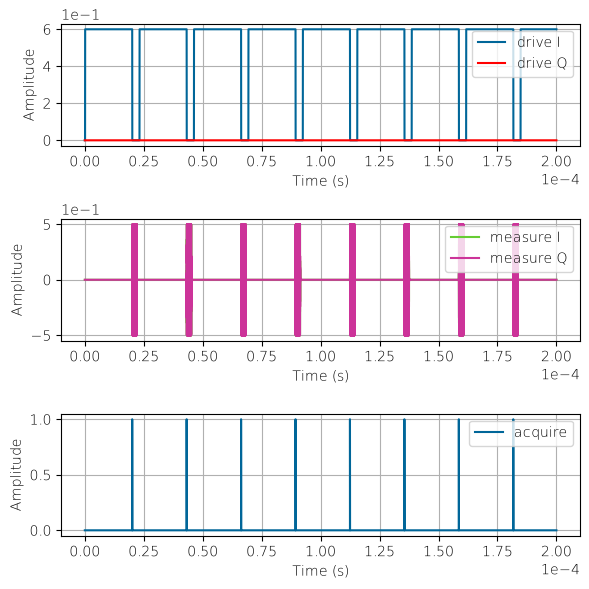

In [31]:
plot_simulation(compiled_qspec, start_time=0, length=200e-6)

In [32]:
# run the experiment
qspec_results = my_session.run(compiled_qspec)

meas_ready()

[2026.07.09 17:01:53.478] INFO    Starting near-time execution...
[2026.07.09 17:01:53.482] INFO    Estimated RT execution time: 9.55 s.
[2026.07.09 17:01:53.493] INFO    Finished near-time execution.


### 3.2.4. Analysis

In [34]:
# get measurement data returned by the instruments
qspec_res = qspec_results.get_data("qb_spec")

# define a frequency axis from the parameters
qspec_freq = lo_settings["qb_lo"] + qspec_results.get_axis("qb_spec")[0]

Qubit parameter qb_freq: -326.4566360998788 MHz


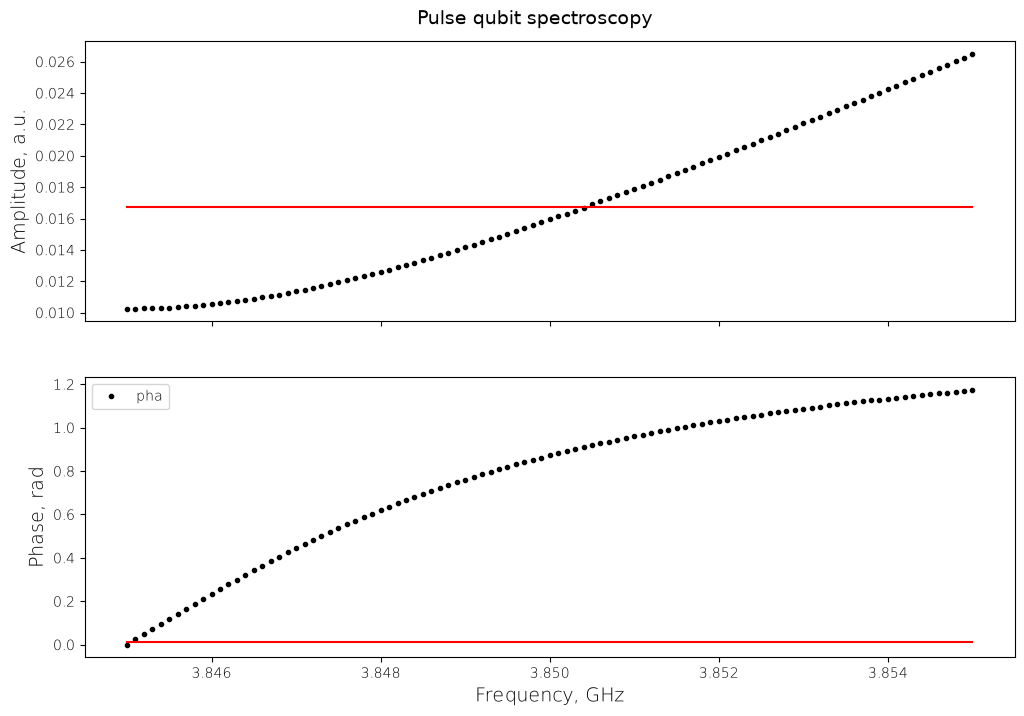

In [35]:
# plot measurement data
fig, (ax1, ax2) = plt.subplots(2, 1, sharex = True, figsize=(12,8))
ax1.plot(qspec_freq / 1e9, abs(qspec_res), ".k", label = 'amp'),
ax2.plot(qspec_freq / 1e9, np.unwrap(np.angle(qspec_res)), ".k", label = 'pha')
ax1.set_ylabel("Amplitude, a.u.", fontsize = 14)
ax2.set_ylabel("Phase, rad", fontsize = 14)
ax2.set_xlabel("Frequency, GHz", fontsize = 14)
plt.suptitle('Pulse qubit spectroscopy', y = 0.92, fontsize = 14)

# increase number of plot points for smooth plotting of fit reults
freq_plot   = np.linspace(qspec_freq[0], qspec_freq[-1], 5 * len(qspec_freq))
guess_freq  = 3.8e9
manual_freq = 3.8e9

# fit measurement data - here assuming an inverted Lorentzian response
popt_pha, pcov_pha = fit_3DSpec(qspec_freq, qspec_res, 1e6, 
                                guess_freq, 10e3, off=2.0, plot=False,
                                bounds=None)

# fit measurement data - here assuming an inverted Lorentzian response
popt_amp, pcov_amp = fit_3DSpec(qspec_freq, abs(qspec_res), 5e5,
                                guess_freq, 10e3, off=0.28, plot=False,
                                bounds=None)

# plot fit results together with measurement data
ax1.plot(freq_plot / 1e9, func_lorentz(freq_plot, *popt_amp), "-r")
ax2.plot(freq_plot / 1e9, func_lorentz(freq_plot, *popt_pha), "-r")

plt.legend()

# update qubit parameters
qubit_parameters.update_parameter("qb_freq", popt_pha[1] - lo_settings["qb_lo"])
print('Qubit parameter qb_freq:', qubit_parameters["qb_freq"] * 1e-6, 'MHz')

In [36]:
Data_TT = {
    'qspec_freq': qspec_freq,
    'qspec_res': qspec_res
}

Data_TT.update(qubit_parameters._params)
Data_TT.update(lo_settings._params)

In [53]:
qubit_parameters

--- qubit_parameters_cooldown_2 ---
ro_freq: 125442103.11770725
ro_amp: 0.5
ro_amp_spec: 0.05
ro_len: 2e-06
ro_len_spec: 4e-06
ro_delay: 0.0
ro_int_delay: 3.3e-07
th_res_freq: 0.0
qb_freq: -326456636.0998788
qb_anharm: 220000000.0
qb_amp_spec: 0.6
qb_len_spec: 2e-05
qb_len: 6e-08
pi_amp: 1.0
pi_half_amp: 0.25
qb_t1: 6e-06
qb_t2_ramsey: 1e-06
ramsey_det: 2000000.0
qb_t2_echo: 1e-06
relax: 0.0005
qb_ef_amp_spec: 0.8

## 3.3. TTS with Flux

In [ ]:
#Qubit spectroscopy
qspec_res_list = []
TTS_popt_list = []

In [ ]:
qubit_parameters['flux_lower_ss'] = -1.9e-05

In [ ]:
print(qubit_parameters['flux_lower_ss'])

In [ ]:
flux_sweep = np.linspace(-0.002, 0.002, 25) * 1e-3
flux_points = qubit_parameters['flux_lower_ss'] + flux_sweep
print(flux_points)

In [ ]:
for i in range(len(flux_sweep)):
    print('Measurement number:', i)
    volt_source.ramp(flux_points[i]*R, 10)
    print('Flux:', flux_points[i])
    
    # Make the TTS
    my_results_TTS = my_session.run(compiled_qspec)
        
    qspec_res = my_results_TTS.get_data("q0_spec")
    qspec_freq = lo_settings["qb_lo"] + my_results_TTS.get_axis("q0_spec")[0]
        
    qspec_res_list.append(qspec_res)

    popt_pha, pcov_pha = fit_3DSpec(qspec_freq, np.unwrap(np.angle(qspec_res)), 
                                    1e6, 4.6e9, 10e3, off=1.84, plot=True, 
                                    bounds=None)

    TTS_popt_list.append(popt_pha)

In [ ]:
qspec_res_arr = np.array(qspec_res_list)
TTS_popt_arr = np.array(TTS_popt_list)

In [ ]:
plt.plot(flux_points, TTS_popt_arr[:,1])

In [ ]:
qubit_parameters['flux_lower_ss'] = -1.85e-05
volt_source.ramp(qubit_parameters['flux_lower_ss'] * R, 10)

## 3.4. ef-Transition Spectroscopy

### 3.4.1. Parameters Settings

In [ ]:
qubit_parameters.update_parameter('qb_anharm', 220e6)
qubit_parameters.update_parameter('qb_ef_amp_spec', 0.2)
qubit_parameters.update_parameter('ro_len', 2e-6)

2e-06

In [40]:
# manual settings of the readout and exitation pulse properties

# exitation:
qubit_parameters.update_parameter("qb_len_spec", 20e-6)
qubit_parameters.update_parameter("qb_ef_amp_spec", 0.8)

print('Qubit spectroscopy length:', qubit_parameters["qb_len_spec"] * 1e6, 'mks')
print('Qubit spectroscopy ef amplitude:', qubit_parameters["qb_ef_amp_spec"])

Qubit spectroscopy length: 20.0 mks
Qubit spectroscopy ef amplitude: 0.8


In [41]:
## define pulses

# qubit pi-pulse for first excited state
x180 = pulse_library.drag(uid="x180", length=24e-9, amplitude=0.5, sigma=0.3, beta=0.2)

# long spectroscopy pulse for e-f transition - frequency will be swept
ef_spec_pulse = pulse_library.const(uid="ef_pulse", length=10e-6, amplitude=1.0)

# readout drive pulse
readout_pulse = pulse_library.const(uid="readout_pulse", length=400e-9, amplitude=0.2)
# readout integration weights
readout_weighting_function = pulse_library.const(
    uid="readout_weighting_function", length=400e-9, amplitude=0.8
)

### 3.4.2. Prepare Experiment

In [42]:
# set up sweep parameter - drive amplitude
qsample_params
start = qubit_parameters["qb_freq"] - qubit_parameters["qb_anharm"] - qspec_range / 2
stop = qubit_parameters["qb_freq"] - qubit_parameters["qb_anharm"] + qspec_range / 2
qspec_num = 501

frequency_sweep = LinearSweepParameter(
    uid="frequency", start=start, stop=stop, count=qspec_num
)

# number of averages
average_exponent = 14  # used for 2^n averages, n=average_exponent, maximum: n = 17

# Create Experiment
exp_ef_spec = Experiment(
    uid="e-f spectroscopy",
    signals=[
        ExperimentSignal("drive"),
        ExperimentSignal("drive_ef"),
        ExperimentSignal("measure"),
        ExperimentSignal("acquire"),
    ],
)
## experimental pulse sequence
# outer loop - real-time, cyclic averaging in standard integration mode
with exp_ef_spec.acquire_loop_rt(
    uid="shots",
    count=pow(2, average_exponent),
    averaging_mode=AveragingMode.CYCLIC,
    acquisition_type=AcquisitionType.INTEGRATION,
):
    # inner loop - real-time frequency sweep of qubit e-f drive pulse
    with exp_ef_spec.sweep(uid="sweep", parameter=frequency_sweep):
        # qubit excitation - pulse amplitude will be swept
        with exp_ef_spec.section(
            uid="qubit_excitation",
            on_system_grid=True,
            alignment=SectionAlignment.RIGHT,
        ):
            exp_ef_spec.play(signal="drive", pulse=x180)
        with exp_ef_spec.section(
            uid="qubit_ef_excitation",
            play_after="qubit_excitation",
            on_system_grid=True,
            alignment=SectionAlignment.RIGHT,
        ):
            exp_ef_spec.play(signal="drive_ef", pulse=ef_spec_pulse)
        # qubit readout pulse and data acquisition
        with exp_ef_spec.section(uid="qubit_readout", play_after="qubit_ef_excitation"):
            # play readout pulse
            exp_ef_spec.play(signal="measure", pulse=readout_pulse)
            # signal data acquisition
            exp_ef_spec.acquire(
                signal="acquire",
                handle="ac_0",
                kernel=readout_weighting_function,
            )
        # relax time after readout - for signal processing and qubit relaxation to groundstate
        with exp_ef_spec.section(uid="relax", length=100e-9):
            exp_ef_spec.reserve(signal="measure")

In [43]:
# define signal maps for qubit 0
map_q0 = {
    "drive": my_setup.logical_signal_groups["q0"].logical_signals["drive"],
    "drive_ef": my_setup.logical_signal_groups["q0"].logical_signals["drive_ef"],
    "measure": my_setup.logical_signal_groups["q0"].logical_signals["measure"],
    "acquire": my_setup.logical_signal_groups["q0"].logical_signals["acquire"],
}

In [44]:
# define experiment calibration
exp_calibration = Calibration(
    {
        "drive_ef": SignalCalibration(
            oscillator=Oscillator(
                # WORKAROUND: when sweeping an oscillator on a logical line using the oscillator switching feature, need to ensure that the uid of the swept oscillator is sorted() first
                uid="ef_drive_osc",
                frequency=frequency_sweep,
                modulation_type=ModulationType.HARDWARE,
            )
        )
    }
)

In [45]:
# set signal map to qubit 0
exp_ef_spec.set_signal_map(map_q0)
exp_ef_spec.set_calibration(exp_calibration)

### 3.4.3. Compile & Run

In [46]:
# run experiment on qubit 0
compiled_exp_ef_spec = my_session.compile(exp_ef_spec)

ef_espec_results = my_session.run(compiled_exp_ef_spec)

[2026.07.09 17:02:28.443] INFO    Starting LabOne Q Compiler run...
[2026.07.09 17:02:28.447] INFO    Schedule completed. [0.003 s]
[2026.07.09 17:02:28.458] INFO    Code generation completed for all AWGs. [0.011 s]
[2026.07.09 17:02:28.460] INFO    Completed compilation step 1 of 1. [0.016 s]
[2026.07.09 17:02:28.463] INFO     ───────────────────────────────────────────────────────────────────── 
[2026.07.09 17:02:28.463] INFO      Device            AWG   SeqC LOC   CT entries   Waveforms   Samples  
[2026.07.09 17:02:28.464] INFO     ───────────────────────────────────────────────────────────────────── 
[2026.07.09 17:02:28.464] INFO      device_shfqc        0         10            0           1      1600  
[2026.07.09 17:02:28.464] INFO      device_shfqc_sg     0         28            3           2     40096  
[2026.07.09 17:02:28.464] INFO     ───────────────────────────────────────────────────────────────────── 
[2026.07.09 17:02:28.464] INFO      TOTAL                         38 

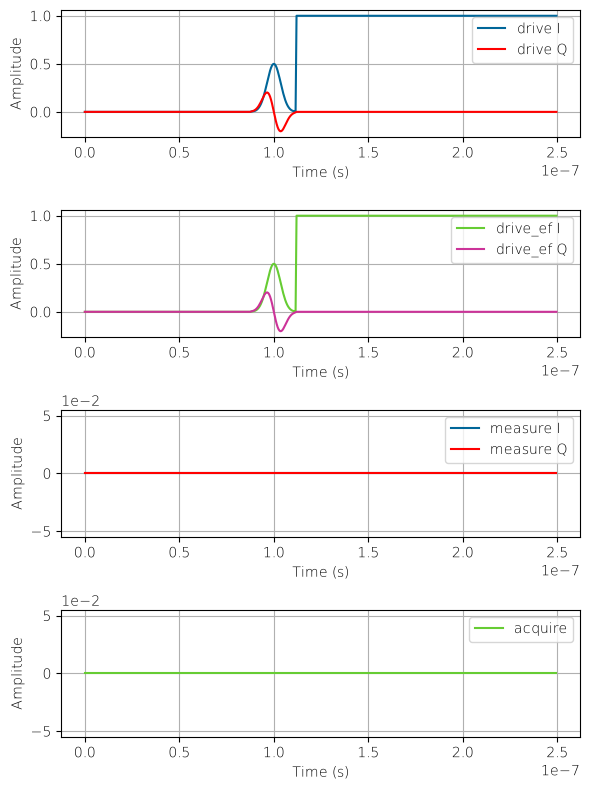

In [47]:
# Plot simulated output signals
plot_simulation(compiled_exp_ef_spec, start_time=0, length=0.25e-6)

### 3.4.4. Analysis

In [49]:
# get measurement data returned by the instruments
ef_espec_res = ef_espec_results.get_data("ac_0")

# define a frequency axis from the parameters
#ef_qspec_freq = drive_Oscillator_q1.frequency + my_results.get_axis("q0_ef_spec")[0]
ef_espec_freq = lo_settings["qb_lo"] + ef_espec_results.get_axis("ac_0")[0]

[1.00000000e+06 1.06785648e+16 1.00000000e+01 1.27756285e+00]
Qubit anharmonism:  220.0 MHz


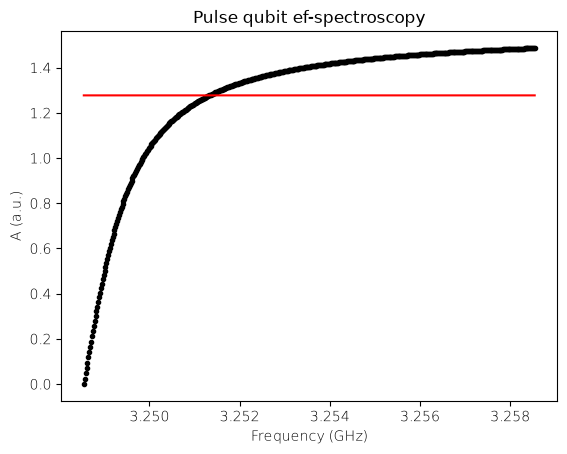

In [50]:
# plot measurement data
fig = plt.figure()
plt.plot(ef_espec_freq / 1e9, np.unwrap(np.angle(ef_espec_res)), ".k")
plt.ylabel("A (a.u.)")
plt.xlabel("Frequency (GHz)")
plt.title('Pulse qubit ef-spectroscopy')

# increase number of plot points for smooth plotting of fit reults
freq_plot = np.linspace(ef_espec_freq[0], ef_espec_freq[-1], 5 * len(ef_espec_freq))

# fit measurement data - here assuming an inverted Lorentzian response
popt, pcov = fit_3DSpec(ef_espec_freq, np.unwrap(np.angle(ef_espec_res)), 
                        1e6, 3.6345e9, 10, off=2.0, plot=False, 
                        bounds=None)
print(popt)


# plot fit results together with measurement data
plt.plot(freq_plot / 1e9, func_lorentz(freq_plot, *popt), "-r")

print('Qubit anharmonism: ', qubit_parameters['qb_anharm']*1e-6, 'MHz')

In [51]:
Data_TT = {
    'espec_freq': ef_espec_freq,
    'espec_res': ef_espec_res
}

Data_TT.update(qubit_parameters._params)
Data_TT.update(lo_settings._params)

In [52]:
qubit_parameters

--- qubit_parameters_cooldown_2 ---
ro_freq: 125442103.11770725
ro_amp: 0.5
ro_amp_spec: 0.05
ro_len: 2e-06
ro_len_spec: 4e-06
ro_delay: 0.0
ro_int_delay: 3.3e-07
th_res_freq: 0.0
qb_freq: -326456636.0998788
qb_anharm: 220000000.0
qb_amp_spec: 0.6
qb_len_spec: 2e-05
qb_len: 6e-08
pi_amp: 1.0
pi_half_amp: 0.25
qb_t1: 6e-06
qb_t2_ramsey: 1e-06
ramsey_det: 2000000.0
qb_t2_echo: 1e-06
relax: 0.0005
qb_ef_amp_spec: 0.8

# 4. Control Pulse Setup

## 4.1. 1st Transition: g-e

### 4.1.1. Amplitude Rabi Experiment

In [ ]:
# qubit drive frequency - defined in calibration on device setup as baseline reference
drive_Oscillator_q0.frequency = qubit_parameters["qb_freq"]
# set oscillator type to hardware to ensure optimal use of the instrument functionality
drive_Oscillator_q0.modulation_type = ModulationType.HARDWARE

In [ ]:
#Set power ranges for drive, measure and aquire
###USUALLY DON'T NEED TO BE USED!!!!!!

####Drive#### Usualy 5 dBm
lsg_q0["drive_line"].range = 10

####Measure###
#lsg_q0["measure_line"].range = -25
# lsg_q0["measure_line"].range = -10 #High Power
lsg_q0["measure_line"].range = -20 #Low Power

####Acquire### Usualy -30
lsg_q0["acquire_line"].range = -35

In [ ]:
#Check ranges
print('Drive line range:', lsg_q0["drive_line"].range, 'dBm')
print('Measure line range:', lsg_q0["measure_line"].range, 'dBm')
print('Acquire line range:', lsg_q0["acquire_line"].range, 'dBm')

In [ ]:
range_params = QBaseParameters(sample=qsample_params,
                                    name=f'range_paramaters_cooldown_{cooldown_nr}',
                                    parameters={'drive': lsg_q0["drive_line"].range,
                                                'drive_ef': lsg_q0["drive_ef_line"].range,
                                                'measure': lsg_q0["measure_line"].range,
                                                'acquire': lsg_q0["acquire_line"].range})

range_params

In [ ]:
#Check frequencies
print('Readout frequency:', qubit_parameters["ro_freq"]*1e-6, 'MHz')
print('Qubit frequency:', qubit_parameters["qb_freq"]*1e-6, 'MHz')
# qubit_parameters.update_parameter("qb_freq", 599.5593508373827 * 1e6)

In [ ]:
#Set readout frequency

# readout pulse frequency resonant with the readout resonator
readout_Oscillator_q0.frequency = qubit_parameters["ro_freq"]
#readout_Oscillator_q0.frequency = qubit_parameters["ro_bare"]
# change oscillator type to software to enable multiplexed qubit readout
readout_Oscillator_q0.modulation_type = ModulationType.SOFTWARE

# demodulation frequency same as readout pulse frequency
acquire_Oscillator_q0.frequency = qubit_parameters["ro_freq"]
#acquire_Oscillator_q0.frequency = qubit_parameters["ro_bare"]
acquire_Oscillator_q0.modulation_type = ModulationType.SOFTWARE

In [ ]:
#change lenght of the qubit exitation pulse
qubit_parameters.update_parameter('qb_len', 300e-9)
#qubit_parameters.add_parameter('qb._len', 50e-9)

print('Qubit exitation pulse length: ', qubit_parameters["qb_len"]*1e9, 'ns')

In [ ]:
# qubit_parameters["relax"] = 7e-5
# qubit_parameters.update_parameter('relax',70e-6)

In [ ]:
readout_low = {'readout_type': 'pulse',
                'readout_pulse': readout_pulse,
                'readout_weighting_function': readout_weighting_function,
                'relax_time': qubit_parameters["relax"],
                'measure_freq': qubit_parameters["ro_freq"],
                'acquire_freq': qubit_parameters["ro_freq"],
                'readout_range': lsg_q0["measure_line"].range,
                'readout_delay': qubit_parameters['ro_int_delay']
               }

In [ ]:
readout_low

In [ ]:
# range of pulse amplitude scan
amp_min = 0
amp_max = 1.0
amp_num = 31

# set up sweep parameter - qubit drive pulse amplitude
rabi_sweep = LinearSweepParameter(
    uid="rabi_amp", start=amp_min, stop=amp_max, count=amp_num
)

# how many averages per point: 2^n_average
n_average = 11

# Rabi excitation pulse - gaussian of unit amplitude - amplitude will be scaled with sweep parameter in experiment
gaussian_pulse = pulse_library.gaussian(
    uid="gaussian_pulse", length=qubit_parameters["qb_len"], amplitude=1.0
)

In [ ]:
exp_rabi = create_rabi(rabi_sweep, 
                       gaussian_pulse, 
                       readout_low, #readout_opt, #readout_low,
                       n_average)

exp_rabi_comp = my_session.compile(exp_rabi)

In [ ]:
# run the experiment on qubit 0
my_results = my_session.run(exp_rabi_comp)

meas_ready()

In [ ]:
# get measurement data returned by the instruments
rabi_res = my_results.get_data("q0_rabi")

# define amplitude axis from qubit parameters
rabi_amp = my_results.get_axis("q0_rabi")[0]

In [ ]:
signal = rabi_res

fig, ax = plt.subplots(2, 2, sharex = True, figsize = (10, 8))

fig.suptitle('Rabi oscillations vs amplitude, $\Delta t_q$ = ' + '{:.0f}'.format(qubit_parameters["qb_len"]*1e9) + 'ns, '+'$N_{av}$ = ' + '{:.0f}'.format(n_average), fontsize=16)

fig.supxlabel("Amplitude (a.u.)")
fig.supylabel("Amplitude (a.u.)")

ax[0,0].plot(rabi_amp, abs(signal), ".k", label = 'amp')
ax[1,0].plot(rabi_amp, np.unwrap(np.angle(signal)), ".k", label = 'phase')
ax[0,1].plot(rabi_amp, np.real(signal), ".k", label = 'real')
ax[1,1].plot(rabi_amp, np.imag(signal), ".k", label = 'imag')

ax[0,0].set_title('amplitude')
ax[1,0].set_title('phase')
ax[0,1].set_title('real part')
ax[1,1].set_title('imaginary part')

amp_plot = np.linspace(rabi_amp[0], rabi_amp[-1], 5 * len(rabi_amp))

popt_amp, pcov_amp = fit_Rabi(rabi_amp, abs(signal), 10, 1, 1, 0.048, plot=False)
popt_pha, pcov_pha = fit_Rabi(rabi_amp, np.unwrap(np.angle(signal)), 10, 1, 1, 0.048, plot=False)
popt_real, pcov_real = fit_Rabi(rabi_amp, np.real(signal), 10, 1, 1, 0.048, plot=False)
popt_imag, pcov_imag = fit_Rabi(rabi_amp, np.imag(signal), 10, 1, 1, 0.048, plot=False)

ax[0,0].plot(amp_plot, func_osc(amp_plot, *popt_amp), "-r")
ax[1,0].plot(amp_plot, func_osc(amp_plot, *popt_pha), "-r")
ax[0,1].plot(amp_plot, func_osc(amp_plot, *popt_real), "-r")
ax[1,1].plot(amp_plot, func_osc(amp_plot, *popt_imag), "-r")

print('fitting results for x180-pulse amplitude:')
print('amp   --- {:4.4f} +/- {:4.4f}'.format(np.pi/popt_amp[0], np.sqrt(np.diag(pcov_amp))[0]))
print('pha   --- {:4.4f} +/- {:4.4f}'.format(np.pi/popt_pha[0], np.sqrt(np.diag(pcov_pha))[0]))
print('real  --- {:4.4f} +/- {:4.4f}'.format(np.pi/popt_real[0], np.sqrt(np.diag(pcov_real))[0]))
print('imag  --- {:4.4f} +/- {:4.4f}'.format(np.pi/popt_imag[0], np.sqrt(np.diag(pcov_imag))[0]))

#qubit_parameters["pi_amp"] = np.pi/popt_pha[0]
#qubit_parameters["pihalf_amp"] = np.pi / 2 / (popt_pha[0])

#save figure
figname = 'Rabi_osc_'
file_path = get_path_to_file(figname, '.png', sample_parameters)
plt.savefig(file_path, dpi=600, format='png', metadata=None,
        bbox_inches=None, pad_inches=0.1,
        facecolor='auto', edgecolor='auto',
        backend=None,
       )

In [ ]:
signal = rabi_res

fig, ax = plt.subplots(3, 1, sharex = True, figsize = (10, 8))

I_zero = np.real(signal)[0]
Q_zero = np.imag(signal)[0]

new_signal = np.sqrt((np.real(signal) - I_zero)**2 + (np.imag(signal) - Q_zero)**2)

fig.suptitle(r'Rabi oscillations vs amplitude, $\Delta t_q$ = ' + '{:.0f}'.format(qubit_parameters["qb_len"]*1e9) + 'ns, '+'$N_{av}$ = ' + '{:.0f}'.format(n_average), fontsize=16)

fig.supxlabel("Amplitude (a.u.)")
fig.supylabel("Amplitude (a.u.)")

ax[0].plot(rabi_amp, np.real(signal), ".k")
ax[1].plot(rabi_amp, np.imag(signal), ".k")
ax[2].plot(rabi_amp, new_signal, ".k")

ax[0].set_title('real')
ax[1].set_title('imag')
ax[2].set_title('norm')

amp_plot = np.linspace(rabi_amp[0], rabi_amp[-1], 5 * len(rabi_amp))

popt_real, pcov_real = fit_Rabi(rabi_amp, np.real(signal), 10, 1, 1, 0.048, plot=False)
popt_imag, pcov_imag = fit_Rabi(rabi_amp, np.imag(signal), 10, 1, 1, 0.048, plot=False)
popt_norm, pcov_norm = fit_Rabi(rabi_amp, new_signal, 10, 1, 1, 0.01, plot=False)

ax[0].plot(amp_plot, func_osc(amp_plot, *popt_real), "-r")
ax[1].plot(amp_plot, func_osc(amp_plot, *popt_imag), "-r")
ax[2].plot(amp_plot, func_osc(amp_plot, *popt_norm), "-r")

print(f"Current pi pulse amplitude: \n{qubit_parameters['pi_amp']}")
print('fitting results for x180-pulse amplitude:')
print('real  --- {:4.4f} +/- {:4.4f}'.format(np.pi/popt_real[0], np.sqrt(np.diag(pcov_real))[0]))
print('imag  --- {:4.4f} +/- {:4.4f}'.format(np.pi/popt_imag[0], np.sqrt(np.diag(pcov_imag))[0]))
print('norm  --- {:4.4f} +/- {:4.4f}'.format(np.pi/popt_norm[0], np.sqrt(np.diag(pcov_norm))[0]))

#save figure
figname = 'Rabi_osc_norm_'
file_path = get_path_to_file(figname, '.png', sample_parameters)
plt.savefig(file_path, dpi=600, format='png', metadata=None,
        bbox_inches=None, pad_inches=0.1,
        facecolor='auto', edgecolor='auto',
        backend=None,
       )

In [ ]:
qubit_parameters.update_parameter("pi_amp", np.pi / (popt_norm[0]))
try:
    qubit_parameters.update_parameter("pihalf_amp", np.pi / 2 / (popt_norm[0]))
except Exception as ex:
    print(ex)
    qubit_parameters.add_parameter("pihalf_amp", np.pi / 2 / (popt_norm[0]))
    print('Added new parameter')

In [ ]:
#plot data on IQ plane
plt.title(r'Rabi oscillations on IQ, $\Delta t_q$ = ' + '{:.0f}'.format(qubit_parameters["qb_len"]*1e9) + 'ns, '+'$N_{av}$ = ' + '{:.0f}'.format(n_average), fontsize=16)

plt.plot(np.real(signal), np.imag(signal), ".k")

popt, pcov = fit_linear(np.real(signal), np.imag(signal), plot=False)

plt.plot(np.real(signal), func_lin(np.real(signal),*popt), 'r')

plt.xlabel('Real, a.u')
plt.ylabel('Imag, a.u')

In [ ]:
Data_rabi = {'rabi_res': rabi_res,
            'rabi_amp': rabi_amp
            }

Data_rabi.update(qubit_parameters._params)
Data_rabi.update(lo_settings._params)

file_name = 'Rabi_ampl_rough_'
file_path = get_path_to_file(file_name, '.mat', sample_parameters)
savemat(file_path, Data_rabi)

#### Set/Update x90 and x180 pulses

In [ ]:
print('Pi amplitude:', qubit_parameters["pi_amp"])
print('Pi length:', qubit_parameters["qb_len"])

In [ ]:
x180 = pulse_library.gaussian(
    uid="x180", length=qubit_parameters["qb_len"], amplitude=qubit_parameters["pi_amp"]
)

x180_drag = pulse_library.drag(
    uid="x180_drag", length=qubit_parameters["qb_len"], amplitude=qubit_parameters["pi_amp"], sigma=0.3, beta=0.2
)

x90 = pulse_library.gaussian(
    uid="x90",
    length=qubit_parameters["qb_len"],
    amplitude=qubit_parameters["pihalf_amp"],
)

### 4.1.2. Rabi Shevron

In [ ]:
results_list = []

detuning_shev = np.linspace(-5, 5, 41)*1e6

In [ ]:
for i in range(len(detuning_shev)):
    print('Measurement number:', i)
    
    # qubit drive frequency - defined in calibration on device setup as baseline reference
    drive_Oscillator_q0.frequency = qubit_parameters["qb_freq"]+detuning_shev[i]
    # set oscillator type to hardware to ensure optimal use of the instrument functionality
    drive_Oscillator_q0.modulation_type = ModulationType.HARDWARE
    
    my_results = my_session.run(exp_rabi)
    results_list.append(my_results.get_data("q0_rabi"))

In [ ]:
rabi_shev_arr = np.array(results_list)

In [ ]:
X = rabi_amp
Y = detuning_shev*1e-6
#Z = np.unwrap(np.angle(rabi_shev_arr))
Z = np.absolute(rabi_shev_arr)
calc.plot_2d(Y, X,Z, flip = False, cmap = 'Reds')
plt.title('Rabi shevron, ABS, $\Delta t_q$ = ' + '{:.0f}'.format(qubit_parameters["qb_len"]*1e9) + 'ns, '+'$N_{av}$ = ' + '{:.0f}'.format(n_average), fontsize=16)
plt.xlabel('Detuning, MHz')
plt.ylabel('Rabi Amplitude')

#save figure
figname = 'Rabi_shevron_'
file_path = get_path_to_file(figname, '.png', sample_parameters)
plt.savefig(file_path, dpi=600, format='png', metadata=None,
        bbox_inches=None, pad_inches=0.1,
        facecolor='auto', edgecolor='auto',
        backend=None,
       )

In [ ]:
Data_rabi = {'rabi_shev': rabi_shev_arr,
               'detuning': detuning_shev,
               'rabi_amp': rabi_amp,
               }

Data_rabi.update(qubit_parameters._params)
Data_rabi.update(lo_settings._params)

file_name = 'Rabi_shev_ge_'
file_path = get_path_to_file(file_name, '.mat', sample_parameters)
savemat(file_path, Data_rabi)

In [ ]:
#Restore proper qubit frequency!

drive_Oscillator_q0.frequency = qubit_parameters["qb_freq"]
# set oscillator type to hardware to ensure optimal use of the instrument functionality
drive_Oscillator_q0.modulation_type = ModulationType.HARDWARE

### 4.1.3. Rabi Frequency Calibration

In [ ]:
#Settings for rabi frequency calibration
# range of pulse amplitude scan
amp_min = 0
amp_max = 1.0 #min([qubit_parameters["pi_amp"] * 2.2, 1.0])
# how many amplitude points to measure
amp_num = 101

# set up sweep parameter - qubit drive pulse amplitude
rabi_sweep = LinearSweepParameter(
    uid="rabi_amp", start=amp_min, stop=amp_max, count=amp_num
)

# how many averages per point: 2^n_average
n_average = 12

# # Rabi excitation pulse - gaussian of unit amplitude - amplitude will be scaled with sweep parameter in experiment
# gaussian_pulse = pulse_library.gaussian(
#     uid="gaussian_pulse", length=20e-9, amplitude=1.0
# )

In [ ]:
rabi_length_arr = np.linspace(50, 400, 36)*1e-9
print(rabi_length_arr)

In [ ]:
freq_test_list= [10]

rabi_list = []
rabi_popt_list = []
rabi_pcov_list = []

for i in range(len(rabi_length_arr)):
    print('Length: ', rabi_length_arr[i]*1e9, 'ns')
    gaussian_pulse_sw = pulse_library.gaussian(
        uid="gaussian_pulse", length=rabi_length_arr[i], amplitude=1.0
    )
    
    exp_rabi_sw = make_rabi(rabi_sweep, 
                         gaussian_pulse_sw, 
                         readout_pulse, 
                         readout_weighting_function, 
                         qubit_parameters["relax"], 
                         n_average)
    
    exp_rabi_sw.set_signal_map(qubit_meas_map)
    # compile
    exp_rabi_sw_comp = my_session.compile(exp_rabi_sw)
    
    rabi_sw_results = my_session.run(exp_rabi_sw_comp)
    
    # get measurement data returned by the instruments
    rabi_res = rabi_sw_results.get_data("q0_rabi")
    rabi_amp = rabi_sw_results.get_axis("q0_rabi")[0]
    
    I_zero = np.real(rabi_res)[0]
    Q_zero = np.imag(rabi_res)[0]
    
    norm_signal = np.sqrt((np.real(rabi_res) - I_zero)**2 + (np.imag(rabi_res) - Q_zero)**2)
    

    popt_norm, pcov_norm = fit_Rabi(rabi_amp, norm_signal, freq_test_list[-1], 1.0, 0.1, 0.048, plot=True)
    freq_test_list.append(popt_norm[0])
    
    rabi_list.append(rabi_res)
    rabi_popt_list.append(popt_norm)
    rabi_pcov_list.append(pcov_norm)
    
rabi_arr = np.array(rabi_list)
rabi_popt_arr = np.array(rabi_popt_list)
rabi_pcov_arr = np.array(rabi_pcov_list)

In [ ]:
X = rabi_amp
Y = rabi_length_arr
#Z = np.unwrap(np.angle(rabi_shev_arr))
Z = np.absolute(rabi_arr)
calc.plot_2d(Y, X,Z, flip = False, cmap = 'Reds')
plt.xlabel('Pulse_length')
plt.ylabel('Rabi_amplitude')

In [ ]:
#x = 1e-6*np.pi / rabi_length_arr
x = 1e-6/ rabi_length_arr
y = np.pi / (rabi_popt_arr[:,0])

popt, pcov = fit_linear(x, y, plot=False)

plt.plot(x, y, '.k')
plt.plot(x, func_lin(x,*popt), 'r')

plt.xlabel('Rabi frequency, MHz')
plt.ylabel('Rabi amplitude')

print('Slope: ', popt[0])
print('Intercept: ', popt[1])

qubit_parameters['rabi_slope'] = popt[0]
qubit_parameters['rabi_intercept'] = popt[1]

In [ ]:
Data_rabi_calib = {'rabi_length':rabi_length_arr,
                   'rabi_data': rabi_arr, 
                   'rabi_amp': rabi_amp,
                   'rabi_popt': rabi_popt_arr,
                   'rabi_pcov': rabi_pcov_arr,
                  }

Data_rabi_calib.update(qubit_parameters)
Data_rabi_calib.update(lo_settings)

file_name = 'Rabi_calib_'
file_path = get_path_to_file(file_name, '.mat', sample_parameters)
savemat(file_path, Data_rabi_calib)

### 4.1.4. T1 Experiment

In [ ]:
# qubit_parameters.update_parameter('relax', 500e-6)

In [ ]:
# delay range for ramsey pulses
t1_min = 0.0
t1_max = 100e-6 #5 * qubit_parameters["qb_t1"]
# how many delay points to sweep
t1_num = 21

# set up sweep parameter
#t1_sweep = LinearSweepParameter(uid="t1_delay", start=t1_min, stop=t1_max, count=t1_num)

#log sweep
def log_sweep_help(t1_min, t1_max, t1_num):
    t1_log_sweep = np.logspace(np.log10(t1_max/t1_num/10), np.log10(t1_max), t1_num-1)
    t1_log_sweep_arr = np.append([0.0], t1_log_sweep)
    return SweepParameter(values=t1_log_sweep_arr)

t1_sweep = log_sweep_help(t1_min, t1_max, t1_num)

# how many averages per point: 2^n_average
n_average = 12

In [ ]:
exp_t1 = create_t1(t1_sweep, 
                   x180, 
                   readout_low,#readout_opt
                   n_average)

exp_t1_comp = my_session.compile(exp_t1)

In [ ]:
# run the experiment on qubit 0
t1_results = my_session.run(exp_t1_comp)

meas_ready()

In [ ]:
# get measurement data returned by the instruments
t1_res = t1_results.get_data("q0_t1")

# define time axis from qubit parameters
t1_delay = t1_results.get_axis("q0_t1")[0]

In [ ]:
#fit the data
popt_sl, pcov_sl = auto_T1_fit(t1_delay, t1_res, data_type = 'rot', plot = True)

#Transform fit parameters to proper formatting for one slice measurements
popt = popt_sl[0,:]
pcov = pcov_sl[0,:,:]

plt.title('Decay, rotated data')
plt.figtext(0.6, 0.5, r'$T_1$ = '+'{:.2f}'.format(1/popt[0]*1e6)+r'$\mu$s')

# update qubit parameters - here relaxation time / qubit lifetime
qubit_parameters.update_parameter("qb_t1", 1 / popt[0])

# T1 error in us
err = np.sqrt(np.diag(pcov))
print(f'T1 = {qubit_parameters["qb_t1"]*1e6:.3f} +- {(err[0]/(popt[0]*popt[0])*1e6):.3f} us')

#save figure
figname = 'T1'
file_path = get_path_to_file(figname, '.png', sample_parameters)
plt.savefig(file_path, dpi=600, format='png', metadata=None,
        bbox_inches=None, pad_inches=0.1,
        facecolor='auto', edgecolor='auto',
        backend=None,
       )

In [ ]:
Data_T1 = {'t1_res': t1_res,
            't1_delay': t1_delay
            }

Data_T1.update(qubit_parameters._params)
Data_T1.update(lo_settings._params)

file_name = 'T1_'
file_path = get_path_to_file(file_name, '.mat', sample_parameters)
savemat(file_path, Data_T1)

In [ ]:
#file_name = 'Qubit_params_dict_lower_ss_after_T1'
#file_path = get_path_to_file(file_name, '.txt', sample_parameters = sample_parameters)
#with open(file_path, 'w') as fp:
    #js.dump(qubit_parameters,fp)

### 4.1.5. Ramsey Experiments

#### A: One-slice experiment

In [ ]:
#Set Ramsey detuning for single sweep
qubit_parameters.update_parameter("ramsey_det", 0.5e6)
qubit_parameters["ramsey_det"]

# qubit_parameters.update_parameter("relax", 100e-6)
#qubit_parameters.update_parameter('qb_t2_ramsey', 10e-6)

In [ ]:
qubit_parameters["ramsey_det"]


In [ ]:
# delay range for ramsey pulses
ramsey_min = 0.0

#ramsey_max = 5.0e-6 
ramsey_max = 15e-6 

# how many delay points to sweep
ramsey_num = 101
#ramsey_num = 151

# set up delay sweep parameter
ramsey_sweep = LinearSweepParameter(
    uid="ramsey_delay", start=ramsey_min, stop=ramsey_max, count=ramsey_num
)

# how many averages per point: 2^n_average
n_average = 12

In [ ]:
exp_ramsey = create_ramsey(ramsey_sweep, 
                           x90, 
                           readout_low, #readout_low,
                           n_average, 
                           qubit_parameters)

exp_ramsey_comp = my_session.compile(exp_ramsey)

In [ ]:
#my_results = my_session.run(exp_ramsey)
ramsey_results = my_session.run(exp_ramsey_comp)

meas_ready()

In [ ]:
# get measurement data returned by the instruments
ramsey_res = ramsey_results.get_data("q0_ramsey")

# define time axis from qubit parameters
ramsey_delay = ramsey_results.get_axis("q0_ramsey")[0]

In [ ]:
# popt[0]/np.pi/2*1e-6 = np.float64(0.5165350234216134) old

In [ ]:
# plot measurement results
fig = plt.figure(figsize=(12,8))

#data = ramsey_res.real
data = ramsey_res.imag
# data = abs(ramsey_res)
# data = np.unwrap(np.angle(ramsey_res))

plt.plot(ramsey_delay, data, ".k") #np.unwrap(np.angle(
#plt.plot(ramsey_delay, np.unwrap(np.angle(ramsey_res)), ".k")
plt.ylabel("A (a.u.)")
plt.xlabel("delay (s)")
plt.title('Ramsey oscillations')

# increase number of plot points for smooth plotting of fit results
delay_plot = np.linspace(ramsey_delay[0], ramsey_delay[-1], 5 * len(ramsey_delay))

## fit measurement data to decaying sinusoidal oscillatio
popt, pcov = fit_Ramsey(
    x=ramsey_delay,
    y=data,
    #np.unwrap(np.angle(ramsey_res)),
    freq=5* qubit_parameters["ramsey_det"],
    phase=0,
    #2 / qubit_parameters["qb_t2_ramsey"],
    rate=1 / 10e-6,
    amp=0.02,
    off=0.129,
    plot=False,
     bounds=[
         [0.1e6, -np.pi, 0.1 / qubit_parameters["qb_t2_ramsey"], 0.0001, -2],
         [50e6, np.pi, 10 / qubit_parameters["qb_t2_ramsey"], 2, 2],
    ],
#    bounds=[
#        [0.01e6, -1.5*np.pi, 0.05 / 6e-5, 0.0001, -4],
#        [150e6, 1.5*np.pi, 30 / 6e-5, 10, 10],
#    ],
)
#print(popt)

# plot fit results together with experimental data
plt.plot(delay_plot, func_decayOsc(delay_plot, *popt), "-r")
plt.figtext(0.6, 0.8, 'T2 = '+'{:.3f}'.format(1/popt[2]*1e6)+'us')
plt.figtext(0.6, 0.75, r'$\Delta$ = '+'{:.3f}'.format(popt[0]/(2*np.pi)*1e-6)+'MHz')

# update qubit parameters - here qubit dephasing time and qubit frequency
#qubit_parameters["qb_t2_ramsey"] = 1 / popt[2]
# qubit_parameters.update_parameter('qb_t2_ramsey', 1 / popt[2])
# qubit_parameters.update_parameter('qb_freq', qubit_parameters['qb_freq'] + qubit_parameters["ramsey_det"] - popt[0]/np.pi/2) #for positive detuning
# qubit_parameters.update_parameter('qb_freq', qubit_parameters['qb_freq'] + qubit_parameters["ramsey_det"] + popt[0]/np.pi/2) #for negative detuning

# T2 Ramsey error in us
err = np.sqrt(np.diag(pcov))
print(f'T2* = {1/popt[2]*1e6:.3f} +- {err[2]/popt[2]*qubit_parameters["qb_t2_ramsey"]*1e6:.3f} us')
print(f'Detuning is {popt[0]/np.pi/2*1e-6:.4} +- {err[0]/np.pi/2*1e-6:.2} MHz')

#save figure
figname = 'Ramsey_slice_'
file_path = get_path_to_file(figname, '.png', sample_parameters)
plt.savefig(file_path, dpi=600, format='png', metadata=None,
        bbox_inches=None, pad_inches=0.1,
        facecolor='auto', edgecolor='auto',
        backend=None,
       )

In [ ]:
qb_f_neg=qubit_parameters['qb_freq'] + qubit_parameters["ramsey_det"] - popt[0]/2/np.pi
qb_f_pos=qubit_parameters['qb_freq'] - qubit_parameters["ramsey_det"] + popt[0]/2/np.pi

In [ ]:
#try pos
qubit_parameters.update_parameter('qb_freq',qb_f_pos)

In [ ]:
#qubit_parameters.update_parameter('qb_freq',47.70797100737143*1e6) #default

In [ ]:
qubit_parameters['qb_freq']

In [ ]:
#try neg
qubit_parameters.update_parameter('qb_freq',qb_f_neg)

#### B: Ramsey fringes

In [ ]:
#set ramsey detuning limitst and point number

ramsey_min_freq = -2
ramsey_max_freq = 2
N_sweep = 21

ramsey_shev_det = np.linspace(ramsey_min_freq, ramsey_max_freq, N_sweep)*1e6

In [ ]:
ramsey_sh_list = []

for i in range(N_sweep):
    ramsey_cal_sh = make_ramsey_calib(qubit_parameters["qb_freq"], ramsey_shev_det[i])
    
    exp_ramsey.set_calibration(ramsey_cal_sh)
    shev_results = my_session.run(exp_ramsey)
    
    ramsey_sh_list.append(shev_results.get_data("q0_ramsey"))

ramsey_fringes_arr = np.array(ramsey_sh_list)

#restore proper calibration
exp_ramsey.set_calibration(ramsey_cal)

In [ ]:
plt.plot(ramsey_delay, np.unwrap(np.angle(ramsey_fringes_arr[25,:])))

In [ ]:
ramsey_fringes_arr.shape

In [ ]:
X = ramsey_shev_det
Y = ramsey_delay
Z = np.absolute(ramsey_fringes_arr)
#Z = np.unwrap(np.angle(ramsey_fringes_arr))
calc.plot_2d(X, Y, Z, flip = False)

# figname = 'Ramsey_fringes_'
# file_path = get_path_to_file(figname, '.png')
# plt.savefig(file_path, dpi=600, format='png', metadata=None,
#         bbox_inches=None, pad_inches=0.1,
#         facecolor='auto', edgecolor='auto',
#         backend=None,
#        )

In [ ]:
Data_ramsey_shev = {'ramsey_fr': ramsey_fringes_arr,
                   'ramsey_delay': ramsey_delay, 
                    'ramsey_fr_det': ramsey_shev_det
               }

Data_ramsey_shev.update(qubit_parameters)
Data_ramsey_shev.update(lo_settings)

file_name = 'Ramsey_fringes_'
file_path = get_path_to_file(file_name, '.mat', sample_parameters)
savemat(file_path, Data_ramsey_shev)

### 4.1.6. Hahn Echo Experiment

In [ ]:
# delay range for echo pulses
echo_min = 0.0
echo_max = 50e-6 # 5.0 * qubit_parameters["qb_t2_echo"]
# how many delay points to sweep
echo_num = 151

# # set up delay sweep parameter - max of sweep parameter is half of max delay since here are two delays in sequence
# echo_sweep = LinearSweepParameter(
#     uid="echo_delay", start=echo_min, stop=echo_max / 2, count=echo_num
# )

echo_sweep = log_sweep_help(echo_min, echo_max/2, echo_num)

# how many averages per point: 2^n_average
n_average = 12

In [ ]:
echo_sweep.stop = echo_max

In [ ]:
exp_echo = create_echo(echo_sweep, 
                       x90, 
                       x180, 
                       readout_low, 
                       n_average)

exp_echo_comp = my_session.compile(exp_echo)

In [ ]:
echo_results = my_session.run(exp_echo_comp)

In [ ]:
# get measurement data returned by the instruments
echo_res = echo_results.get_data("q0_echo")

# define time axis from qubit parameters
echo_delay = echo_results.get_axis("q0_echo")[0]

In [ ]:
# plot measurement results - multiply delay by factor of two to get full sequence length
fig = plt.figure()
#plt.plot(2 * echo_delay, abs(echo_res), ".k") #np.unwrap(np.angle(
plt.plot(2 * echo_delay, np.unwrap(np.angle(echo_res)), ".k")
plt.ylabel("A (a.u.)")
plt.xlabel("delay (s)")
plt.title('Hahn echo')

# increase number of plot points for smooth plotting of fit results
delay_plot = np.linspace(echo_delay[0], 2 * echo_delay[-1], 5 * len(echo_delay))

## fit measurement data to decaying sinusoidal oscillatio
#popt, pcov = fit_T1(2 * echo_delay, abs(echo_res), 1e6, 0, -1, plot=False)
popt, pcov = fit_T1(2 * echo_delay, np.unwrap(np.angle(echo_res)), 1e6, 0, -1, plot=False)
print(popt)

# plot fit results together with experimental data
plt.plot(delay_plot, func_exp(delay_plot, *popt), "-r")

# update qubit parameters - here qubit dephasing time
# qubit_parameters["qb_t2_echo"] = 1 / popt[0]
print(1 / popt[0] * 1e6, ' us')

# T2 Echo error in us
err = np.sqrt(np.diag(pcov))
#print(f'T2E = {qubit_parameters["qb_t2_echo"]*1e6:.3f} +- {err[2]/popt[2]*qubit_parameters["qb_t2_echo"]*1e6:.3f} us')

#Save figure
figname = 'Hahn_echo'
file_path = get_path_to_file(figname, '.png', sample_parameters)
plt.savefig(file_path, dpi=600, format='png', metadata=None,
        bbox_inches=None, pad_inches=0.1,
        facecolor='auto', edgecolor='auto',
        backend=None,
       )

In [ ]:
Data_hahn_echo = {'echo_res': echo_res,
               'echo_delay': echo_delay
               }

Data_hahn_echo.update(qubit_parameters)
Data_hahn_echo.update(lo_settings)

file_name = 'Hahn_echo_'
file_path = get_path_to_file(file_name, '.mat', sample_parameters)
savemat(file_path, Data_hahn_echo)

In [ ]:
file_name = 'Qubit_params_dict'
file_path = get_path_to_file(file_name, '.txt', sample_parameters)
with open(file_path, 'w') as fp:
    js.dump(qubit_parameters,fp)

### 4.1.7. Rabi Error Amplification

#### x90 pulse

In [ ]:
max_pulses = 15
n_average = 12

rabi_err_amp_flips = np.arange(1, max_pulses+1, 2)
flips_sweep = SweepParameter(values=rabi_err_amp_flips)

print(f'Repition sequence: {rabi_err_amp_flips}')
print(f'Approximate length of longest pulse sequence: {rabi_err_amp_flips.max() * x90.length * 1e6} us')

# qubit_parameters.update_parameter('relax',  200e-6)
# readout_opt['relax_time'] = qubit_parameters['relax']

In [ ]:
exp_rabi_error_amp_eg_x90 = create_rabi_error_amp(flips_sweep, x180, x90, 
                                              readout_low,
                                              n_average,
                                             target_pulse='x90eg')

exp_rabi_error_amp_eg_comp_x90 = my_session.compile(exp_rabi_error_amp_eg_x90)

# show_pulse_sheet("Rabi Error Amplification", exp_rabi_error_amp_eg_comp)

In [ ]:
rabi_err_amp_results_x90 = my_session.run(exp_rabi_error_amp_eg_comp_x90)

In [ ]:
# get measurement data returned by the instruments
rabi_err_amp_res = rabi_err_amp_results_x90.get_data("q0_rabi")
rabi_err_amp_res_0 = rabi_err_amp_results_x90.get_data("calib_0")
rabi_err_amp_res_1 = rabi_err_amp_results_x90.get_data("calib_1")

In [ ]:
fig, ax = plt.subplots()
amp = np.abs(rabi_err_amp_res)

ax.scatter(rabi_err_amp_flips-1, amp)

ax.set_ylabel('Amplitude (a.u.)')
ax.set_xlabel('Number of applied pi/2 pulses')

axa = ax.twiny()
axa.set_xlabel('Approximate Pulse Sequence Duration (us)')
axa.plot(rabi_err_amp_flips * x90.length * 1e6, np.abs(rabi_err_amp_res), alpha=0)

plot_flips = np.linspace(1, max_pulses + 1, 501)
print(rabi_err_amp_flips)

calib_amp = np.abs(rabi_err_amp_res_0 - rabi_err_amp_res_1) / 2

try:
    popt_amp, pcov_amp = fit_osc_fixed_amp_phase(rabi_err_amp_flips - 1, amp, 
                                  freq=1.5, 
                                  fixed_phase=np.pi / 2, 
                                  fixed_amp=calib_amp, 
                                  off=np.mean(amp))
    popt_amp = list(popt_amp)
    popt_amp.insert(1, np.pi / 2)
    popt_amp.insert(2, calib_amp)
    ax.plot(plot_flips - 1, func_osc(plot_flips - 1 , *popt_amp), "-r")
    # print(popt_amp)

except RuntimeError as ex:
    print('ERROR!')
    print(ex, end='\n\n')
    
ax.hlines([np.abs(rabi_err_amp_res_0)], plot_flips.min(), plot_flips.max(), color='gray', linestyle='dashed')
ax.hlines([np.abs(rabi_err_amp_res_1)], plot_flips.min(), plot_flips.max(), color='gray', linestyle='dotted')

amp_corr = 0.5 * np.pi / popt_amp[0]
print(f'Current x90 amplitude: {qubit_parameters["pihalf_amp"]}')
print(f'Amplitude correction factor: {amp_corr}')

#### Update x90 pulse

In [ ]:
print(f'Old x90 amplitude: {qubit_parameters["pihalf_amp"]}')
qubit_parameters.update_parameter("pihalf_amp", qubit_parameters["pihalf_amp"] * amp_corr)
print(f'New x90 amplitude: {qubit_parameters["pihalf_amp"]}')

In [ ]:
amp_corr

In [ ]:
x90 = pulse_library.gaussian(
    uid="x90", length=qubit_parameters["qb_len"], amplitude=qubit_parameters["pihalf_amp"]
)

#### x180 pulse

In [ ]:
#qubit_parameters.update_parameter("pihalf_amp", qubit_parameters["pi_amp"]/2)

In [ ]:
max_pulses = 15
n_average = 12

rabi_err_amp_flips = np.arange(0, max_pulses+1)
flips_sweep = SweepParameter(values=rabi_err_amp_flips)

print(f'Repition sequence: {rabi_err_amp_flips}')
print(f'Approximate length of longest pulse sequence: {(rabi_err_amp_flips.max() * x180.length + x90.length) * 1e6} us')

# qubit_parameters.update_parameter('relax',  150e-6)
# readout_opt['relax_time'] = qubit_parameters['relax']

In [ ]:
#qubit_parameters.update_parameter('relax',  400e-6)

In [ ]:
exp_rabi_error_amp_eg = create_rabi_error_amp(flips_sweep, x180, x90, 
                                              readout_low,
                                              n_average,
                                             target_pulse='x180eg')

exp_rabi_error_amp_eg_comp = my_session.compile(exp_rabi_error_amp_eg)

# show_pulse_sheet("Rabi Error Amplification", exp_rabi_error_amp_eg_comp)

In [ ]:
rabi_err_amp_results = my_session.run(exp_rabi_error_amp_eg_comp)

In [ ]:
# get measurement data returned by the instruments
rabi_err_amp_res = rabi_err_amp_results.get_data("q0_rabi")
rabi_err_amp_res_0 = rabi_err_amp_results.get_data("calib_0")
rabi_err_amp_res_1 = rabi_err_amp_results.get_data("calib_1")

In [ ]:
fig, ax = plt.subplots()

ax.scatter(rabi_err_amp_flips, np.abs(rabi_err_amp_res))

ax.set_ylabel('Amplitude (a.u.)')
ax.set_xlabel('Number of applied pi pulses')

axa = ax.twiny()
axa.set_xlabel('Approximate Pulse Sequence Duration (us)')
axa.plot((rabi_err_amp_flips * x180.length + x90.length) * 1e6, np.abs(rabi_err_amp_res), alpha=0)

plot_flips = np.linspace(0, max_pulses + 1, 501)

amp = np.abs(rabi_err_amp_res)
calib_amp = np.abs(rabi_err_amp_res_0 - rabi_err_amp_res_1) / 2

try:
    popt_amp, pcov_amp = fit_osc_fixed_amp_phase(rabi_err_amp_flips, amp, 
                                  freq=np.pi, 
                                  fixed_phase=np.pi / 2, 
                                  fixed_amp=calib_amp, 
                                  off=np.mean(amp))
    popt_amp = list(popt_amp)
    popt_amp.insert(1, np.pi / 2)
    popt_amp.insert(2, calib_amp)
    ax.plot(plot_flips, func_osc(plot_flips, *popt_amp), "-r")

except RuntimeError as ex:
    print('ERROR!')
    print(ex, end='\n\n')
    
ax.hlines([np.abs(rabi_err_amp_res_0)], plot_flips.min(), plot_flips.max(), color='gray', linestyle='dashed')
ax.hlines([np.abs(rabi_err_amp_res_1)], plot_flips.min(), plot_flips.max(), color='gray', linestyle='dotted')

amp_corr = np.pi / popt_amp[0]
print(f'Current x180 amplitude: {qubit_parameters["pi_amp"]}')
print(f'Amplitude correction factor: {amp_corr}')

#### Update x180 pulse

In [ ]:
print(f'Old x180 amplitude: {qubit_parameters["pi_amp"]}')
qubit_parameters.update_parameter("pi_amp", qubit_parameters["pi_amp"] * amp_corr)
print(f'New x180 amplitude: {qubit_parameters["pi_amp"]}')

In [ ]:
x180 = pulse_library.gaussian(
    uid="x180", length=qubit_parameters["qb_len"], amplitude=qubit_parameters["pi_amp"]
)

## 4.2. 2nd Transition: e-f

### 4.2.1. Amplitude Rabi Experiment e-f

In [ ]:
# range of pulse amplitude scan
amp_min = 0
amp_max = 1.0 #min([qubit_parameters["pi_amp"] * 2.2, 1.0])
# how many amplitude points to measure
amp_num = 51

# set up sweep parameter - qubit drive pulse amplitude
rabi_ef_sweep = LinearSweepParameter(
    uid="rabi_ef_amp", start=amp_min, stop=amp_max, count=amp_num
)

# qubit_parameters.add_parameter("qb_ef_len", 50e-9)
qubit_parameters.update_parameter("qb_ef_len", 300e-9)
# how many averages per point: 2^n_average
n_average = 12

In [ ]:
#qubit_parameters.update_parameter("qb_ef_freq", -0.16561999999999966*1e6)

In [ ]:
qubit_parameters["qb_ef_len"]

In [ ]:
gaussian_ef = pulse_library.gaussian(
    uid="gaussian_ef", length=qubit_parameters["qb_ef_len"], amplitude=1.0
)

#qubit_parameters["qb_len"]

In [ ]:
# qubit_parameters['qb_ef_freq'] = 1
#qubit_parameters.update_parameter('qb_ef_freq', qubit_parameters["qb_freq"] - qubit_parameters['qb_anharm'])
print('Qubit ef transition frequency: ', qubit_parameters['qb_ef_freq']*1e-6, 'MHz')

In [ ]:
detuning_ef = 0 #e6

# qubit drive frequency - defined in calibration on device setup as baseline reference
drive_ef_Oscillator_q0.frequency = qubit_parameters["qb_ef_freq"] + detuning_ef
# set oscillator type to hardware to ensure optimal use of the instrument functionality
drive_ef_Oscillator_q0.modulation_type = ModulationType.HARDWARE

In [ ]:
exp_rabi_ef = create_rabi_ef(rabi_ef_sweep, 
                             gaussian_ef, 
                             readout_opt,
                             #readout_low,
                             n_average, 
                             x180, 
                             ge_amp = 1.0, 
                             n_ge_pulses = 2)

exp_rabi_ef_comp = my_session.compile(exp_rabi_ef)

show_pulse_sheet("Rabi-ef", exp_rabi_ef_comp)

In [ ]:
#my_results = my_session.run(exp_rabi_ef_comp)

rabi_ef_results = my_session.run(exp_rabi_ef_comp)

In [ ]:
# get measurement data returned by the instruments
rabi_ef_res = rabi_ef_results.get_data("q0_rabi_ef")

# define amplitude axis from qubit parameters
rabi_ef_amp = rabi_ef_results.get_axis("q0_rabi_ef")[0]

In [ ]:
# plot measurement data
fig = plt.figure()
plt.plot(rabi_ef_amp, abs(rabi_ef_res), ".k")
plt.ylabel("A (a.u.)")
# plt.plot(rabi_ef_amp, np.unwrap(np.angle(rabi_ef_res)), ".k")
# plt.ylabel("phase (deg)")
plt.xlabel("amplitude (a.u.)")
plt.title('Rabi oscillations for ef-transition')
#ylim = [0.0370, 0.0400]
#plt.ylim(ylim)

# increase number of plot points for smooth plotting of fit results
ef_amp_plot = np.linspace(rabi_ef_amp[0], rabi_ef_amp[-1], 5 * len(rabi_ef_amp))

# fit measurement results - assume sinusoidal oscillation with drive amplitude
popt, pcov = fit_Rabi(rabi_ef_amp, abs(rabi_ef_res), 20, 1.0, 1.0, 0.1626, plot=False)
# popt, pcov = fit_Rabi(rabi_ef_amp, np.unwrap(np.angle(rabi_ef_res)), 10, 1.0, 0.1, -1.9, plot=False)

# plot fit results together with measurement data
plt.plot(ef_amp_plot, func_osc(ef_amp_plot, *popt), "-r")
#plt.plot(ef_amp_plot, func_decayOsc(ef_amp_plot, *popt), "-r")
# update qubit parameters - pulse amplitdues for pi and pi/2 pulses
# qubit_parameters.update_parameter("pi_ef_amp", np.pi / (popt[0]))
print(qubit_parameters["pi_ef_amp"])

#qubit_parameters["pihalf_ef_amp"] = np.pi / 2 / (popt[0])
#print(qubit_parameters["pihalf_ef_amp"])

print(np.pi / (popt[0]))

#Nmin = np.argmax(func_decayOsc(ef_amp_plot, *popt))
#print(ef_amp_plot[Nmin])

# qubit_parameters["pi_ef_amp"] = ef_amp_plot[Nmin]
# print(qubit_parameters["pi_ef_amp"])

# qubit_parameters["pihalf_ef_amp"] = ef_amp_plot[Nmin] / 2
# print(qubit_parameters["pihalf_ef_amp"])

In [ ]:
signal = rabi_ef_res

fig, ax = plt.subplots(3, 1, sharex = True, figsize = (10, 8))

I_zero = np.real(signal)[0]
Q_zero = np.imag(signal)[0]

new_signal = np.sqrt((np.real(signal) - I_zero)**2 + (np.imag(signal) - Q_zero)**2)

fig.suptitle('Rabi oscillations vs pulse amplitude', fontsize=16)

fig.supxlabel("Amplitude (a.u.)")
fig.supylabel("Amplitude (a.u.)")

ax[0].plot(rabi_ef_amp, np.real(signal), ".k")
ax[1].plot(rabi_ef_amp, np.imag(signal), ".k")
ax[2].plot(rabi_ef_amp, new_signal, ".k")

ax[0].set_title('real part')
ax[1].set_title('imaginary part')
ax[2].set_title('norm')

amp_ef_plot = np.linspace(rabi_ef_amp[0], rabi_ef_amp[-1], 5 * len(rabi_ef_amp))

popt_real, pcov_real = fit_Ramsey(rabi_ef_amp, np.real(signal),
    30, 0, 2,
    amp=0.01, off=2.16, plot=False)
popt_imag, pcov_imag = fit_Ramsey(rabi_ef_amp, np.imag(signal),
    30, 0, 2,
    amp=0.001, off=0.45, plot=False)
popt_norm, pcov_norm = fit_Ramsey(rabi_ef_amp[:], new_signal[:],
    30, 0, 2,
    amp=0.001, off=2e-3, plot=False)

ax[0].plot(amp_ef_plot, func_decayOsc(amp_ef_plot, *popt_real), "-r")
ax[1].plot(amp_ef_plot, func_decayOsc(amp_ef_plot, *popt_imag), "-r")
ax[2].plot(amp_ef_plot, func_decayOsc(amp_ef_plot, *popt_norm), "-r")


print('fitting results for x180-pulse amplitude:')
print('real  --- {:4.4f} +/- {:4.4f}'.format(np.pi/popt_real[0], np.pi*np.sqrt(np.diag(pcov_real))[0]/(popt_real[0])**2))
print('imag  --- {:4.4f} +/- {:4.4f}'.format(np.pi/popt_imag[0], np.pi*np.sqrt(np.diag(pcov_imag))[0]/(popt_imag[0])**2))
print('norm  --- {:4.4f} +/- {:4.4f}'.format(np.pi/popt_norm[0], np.pi*np.sqrt(np.diag(pcov_norm))[0]/(popt_norm[0])**2))

Nmax = np.argmax(func_decayOsc(amp_ef_plot, *popt_norm))
print(amp_ef_plot[Nmax])

# qubit_parameters["pi_ef_amp"] = amp_ef_plot[Nmax]
# qubit_parameters["pihalf_ef_amp"] = amp_ef_plot[Nmax] / 2
# print(qubit_parameters["pi_ef_amp"])
# print(qubit_parameters["pihalf_ef_amp"])

#qubit_parameters.update_parameter("pi_ef_amp", np.pi/popt_norm[0])
print(qubit_parameters["pi_ef_amp"])

#qubit_parameters.update_parameter("pihalf_ef_amp", np.pi / 2 / (popt_norm[0]))
print(qubit_parameters["pihalf_ef_amp"])

# qubit_parameters["pi_ef_amp"] = np.pi/popt_real[0]
#print(qubit_parameters["pi_ef_amp"])

# qubit_parameters["pihalf_ef_amp"] = np.pi / 2 / (popt_real[0])
# print(qubit_parameters["pihalf_ef_amp"])

In [ ]:
#qubit_parameters.add_parameter("pi_ef_amp", np.pi/popt_norm[0])
#qubit_parameters.add_parameter("pihalf_ef_amp", np.pi / 2 / (popt_norm[0]))


In [ ]:
#set a pi_ef pulse
x180_ef = pulse_library.gaussian(
    uid="x180_ef", length=qubit_parameters["qb_ef_len"], amplitude=qubit_parameters["pi_ef_amp"]
)

#set a pi_ef pulse
x90_ef = pulse_library.gaussian(
    uid="x90_ef", length=qubit_parameters["qb_ef_len"], amplitude=qubit_parameters["pi_ef_amp"]/2
)

### 4.2.2. Rabi Error Amplification

#### x90 pulse

In [ ]:
max_pulses = 19
n_average = 13

rabi_err_amp_flips = np.arange(1, max_pulses+1, 2)
flips_sweep = SweepParameter(values=rabi_err_amp_flips)

print(f'Repition sequence: {rabi_err_amp_flips}')
print(f'Approximate length of longest pulse sequence: {(rabi_err_amp_flips.max() * x90_ef.length + 2 * x180.length) * 1e6} us')

# qubit_parameters.update_parameter('relax',  200e-6)
# readout_opt['relax_time'] = qubit_parameters['relax']

In [ ]:
exp_rabi_error_amp_ef_x90 = create_rabi_error_amp_ef(flips_sweep, x180, x90, x180_ef, x90_ef,
                                              readout_opt,
                                              n_average,
                                             target_pulse='x90ef')

exp_rabi_error_amp_ef_comp_x90 = my_session.compile(exp_rabi_error_amp_ef_x90)

# show_pulse_sheet("Rabi Error Amplification ef", exp_rabi_error_amp_ef_comp_x90)

In [ ]:
rabi_err_amp_results_x90_ef = my_session.run(exp_rabi_error_amp_ef_comp_x90)

In [ ]:
# get measurement data returned by the instruments
rabi_err_amp_res = rabi_err_amp_results_x90_ef.get_data("q0_rabi")
rabi_err_amp_res_0 = rabi_err_amp_results_x90_ef.get_data("calib_0")
rabi_err_amp_res_1 = rabi_err_amp_results_x90_ef.get_data("calib_1")

In [ ]:
fig, ax = plt.subplots()
amp = np.abs(rabi_err_amp_res)

ax.scatter(rabi_err_amp_flips-1, amp)

ax.set_ylabel('Amplitude (a.u.)')
ax.set_xlabel('Number of applied pi/2 pulses')

axa = ax.twiny()
axa.set_xlabel('Approximate Pulse Sequence Duration (us)')
axa.plot((rabi_err_amp_flips * x90_ef.length + 2 * x180.length) * 1e6, np.abs(rabi_err_amp_res), alpha=0)

plot_flips = np.linspace(1, max_pulses + 1, 501)
print(rabi_err_amp_flips)

calib_amp = np.abs(rabi_err_amp_res_0 - rabi_err_amp_res_1) / 2

try:
    popt_amp, pcov_amp = fit_osc_fixed_amp_phase(rabi_err_amp_flips - 1, amp, 
                                  freq=1.5, 
                                  fixed_phase=np.pi / 2, 
                                  fixed_amp=calib_amp, 
                                  off=np.mean(amp))
    popt_amp = list(popt_amp)
    popt_amp.insert(1, np.pi / 2)
    popt_amp.insert(2, calib_amp)
    ax.plot(plot_flips - 1, func_osc(plot_flips - 1 , *popt_amp), "-r")
    # print(popt_amp)

except RuntimeError as ex:
    print('ERROR!')
    print(ex, end='\n\n')
    
ax.hlines([np.abs(rabi_err_amp_res_0)], plot_flips.min(), plot_flips.max(), color='gray', linestyle='dashed')
ax.hlines([np.abs(rabi_err_amp_res_1)], plot_flips.min(), plot_flips.max(), color='gray', linestyle='dotted')

amp_corr = 0.5 * np.pi / popt_amp[0]
print(f'Current x90 ef amplitude: {qubit_parameters["pihalf_ef_amp"]}')
print(f'Amplitude correction factor: {amp_corr}')

#### Update x90 pulse

In [ ]:
print(f'Old x90 ef amplitude: {qubit_parameters["pihalf_ef_amp"]}')
qubit_parameters.update_parameter("pihalf_ef_amp", qubit_parameters["pihalf_ef_amp"] * amp_corr)
print(f'New x90 ef amplitude: {qubit_parameters["pihalf_ef_amp"]}')

In [ ]:
x90_ef = pulse_library.gaussian(
    uid="x90_ef", length=qubit_parameters["qb_ef_len"], amplitude=qubit_parameters["pihalf_ef_amp"]
)

#### x180 pulse

In [ ]:
max_pulses = 25
n_average = 12

rabi_err_amp_flips = np.arange(0, max_pulses+1)
flips_sweep = SweepParameter(values=rabi_err_amp_flips)

print(f'Repition sequence: {rabi_err_amp_flips}')
print(f'Approximate length of longest pulse sequence: {(rabi_err_amp_flips.max() * x180_ef.length + 2 * x180.length + x90_ef.length) * 1e6} us')

# qubit_parameters.update_parameter('relax',  150e-6)
# readout_opt['relax_time'] = qubit_parameters['relax']

In [ ]:
exp_rabi_error_amp_ef = create_rabi_error_amp_ef(flips_sweep, x180, x90, x180_ef, x90_ef,
                                              readout_opt,
                                              n_average,
                                             target_pulse='x180ef')

exp_rabi_error_amp_ef_comp = my_session.compile(exp_rabi_error_amp_ef)

# show_pulse_sheet("Rabi Error Amplification", exp_rabi_error_amp_eg_comp)

In [ ]:
rabi_err_amp_results = my_session.run(exp_rabi_error_amp_ef_comp)

In [ ]:
# get measurement data returned by the instruments
rabi_err_amp_res = rabi_err_amp_results.get_data("q0_rabi")
rabi_err_amp_res_0 = rabi_err_amp_results.get_data("calib_0")
rabi_err_amp_res_1 = rabi_err_amp_results.get_data("calib_1")

In [ ]:
fig, ax = plt.subplots()

ax.scatter(rabi_err_amp_flips, np.abs(rabi_err_amp_res))

ax.set_ylabel('Amplitude (a.u.)')
ax.set_xlabel('Number of applied pi pulses')

axa = ax.twiny()
axa.set_xlabel('Approximate Pulse Sequence Duration (us)')
axa.plot((rabi_err_amp_flips * x180_ef.length + 2 * x180.length + x90_ef.length) * 1e6, np.abs(rabi_err_amp_res), alpha=0)

plot_flips = np.linspace(0, max_pulses + 1, 501)

amp = np.abs(rabi_err_amp_res)
calib_amp = np.abs(rabi_err_amp_res_0 - rabi_err_amp_res_1) / 2

try:
    popt_amp, pcov_amp = fit_osc_fixed_amp_phase(rabi_err_amp_flips, amp, 
                                  freq=np.pi, 
                                  fixed_phase=np.pi / 2, 
                                  fixed_amp=calib_amp, 
                                  off=np.mean(amp))
    popt_amp = list(popt_amp)
    popt_amp.insert(1, np.pi / 2)
    popt_amp.insert(2, calib_amp)
    ax.plot(plot_flips, func_osc(plot_flips, *popt_amp), "-r")

except RuntimeError as ex:
    print('ERROR!')
    print(ex, end='\n\n')
    
ax.hlines([np.abs(rabi_err_amp_res_0)], plot_flips.min(), plot_flips.max(), color='gray', linestyle='dashed')
ax.hlines([np.abs(rabi_err_amp_res_1)], plot_flips.min(), plot_flips.max(), color='gray', linestyle='dotted')

amp_corr = np.pi / popt_amp[0]
print(f'Current x180 ef amplitude: {qubit_parameters["pi_ef_amp"]}')
print(f'Amplitude correction factor: {amp_corr}')

#### Update x180 pulse

In [ ]:
print(f'Old x180 ef amplitude: {qubit_parameters["pi_ef_amp"]}')
qubit_parameters.update_parameter("pi_ef_amp", qubit_parameters["pi_ef_amp"] * amp_corr)
print(f'New x180 ef amplitude: {qubit_parameters["pi_ef_amp"]}')

In [ ]:
x180_ef = pulse_library.gaussian(
    uid="x180_ef", length=qubit_parameters["qb_ef_len"], amplitude=qubit_parameters["pi_ef_amp"]
)

### 4.2.3. Rabi shevron e-f

In [ ]:
results_list = []

detuning_ef = np.linspace(-20.0, 20.0, 31)*1e6

In [ ]:
(qubit_parameters["qb_ef_freq"] + lo_settings['qb_lo']) * 1e-9

In [ ]:
for i in range(len(detuning_ef)):
    print('Measurement number:', i)
    # qubit drive frequency - defined in calibration on device setup as baseline reference
    drive_ef_Oscillator_q0.frequency = qubit_parameters["qb_ef_freq"] + detuning_ef[i]
    # set oscillator type to hardware to ensure optimal use of the instrument functionality
    drive_ef_Oscillator_q0.modulation_type = ModulationType.HARDWARE
    
    my_results = my_session.run(exp_rabi_ef)
    results_list.append(my_results.get_data("q0_rabi_ef"))
    
results_arr = np.array(results_list)

In [ ]:
i = 15
#plt.plot(rabi_ef_amp, np.unwrap(np.angle(results_list[11])), "-o")
plt.plot(rabi_ef_amp, results_list[i].imag, "-o")
#plt.plot(rabi_ef_amp, np.unwrap(np.angle(results_list[23])), "-o")
print(detuning_ef[i]*1e-6, 'MHz')

In [ ]:
X = rabi_ef_amp
Y = detuning_ef
# Z = np.unwrap(np.angle(results_arr))
#Z = np.absolute(results_arr)
Z = np.imag(results_arr)
calc.plot_2d(Y, X,Z, flip = False, cmap = 'Reds')

In [ ]:
# qubit_parameters.update_parameter("qb_ef_freq", qubit_parameters["qb_ef_freq"] + 15e6)

In [ ]:
Data_ef_rabi = {'rabi_shev_ef': results_arr,
               'detuning_ef': detuning_ef,
               'rabi_ef_amp': rabi_ef_amp,
               }

Data_ef_rabi.update(qubit_parameters._params)
Data_ef_rabi.update(lo_settings._params)

file_name = 'Rabi_shev_ef'
file_path = get_path_to_file(file_name, '.mat', sample_parameters)
savemat(file_path, Data_ef_rabi)

In [ ]:
file_name = 'Qubit_params'
file_path = get_path_to_file(file_name, '.txt', sample_parameters)
with open(file_path, 'w') as fp:
    js.dump(qubit_parameters,fp)

### 4.2.4. T1 Experiement e-f

In [ ]:
# delay range for ramsey pulses
t1_min = 0.0
t1_max = 5e-6 #5 * qubit_parameters["qb_t1"]
# how many delay points to sweep
t1_num = 31

# set up sweep parameter
t1_ef_sweep = LinearSweepParameter(uid="t1_delay", start=t1_min, stop=t1_max, count=t1_num)

# how many averages per point: 2^n_average
n_average = 13

In [ ]:
exp_T1_ef = create_T1_ef_1(t1_ef_sweep, 
                           x180_ef, 
                           readout_low, 
                           n_average, 
                           x180, 
                           ge_amp = 1.0)

exp_T1_ef_comp = my_session.compile(exp_T1_ef)

#show_pulse_sheet("Decay-ef", exp_T1_ef_comp)

In [ ]:
T1_ef_results = my_session.run(exp_T1_ef_comp)

In [ ]:
# get measurement data returned by the instruments
t1_ef_res = T1_ef_results.get_data("q0_t1_ef")

# define amplitude axis from qubit parameters
t1_ef_delay = T1_ef_results.get_axis("q0_t1_ef")[0]

In [ ]:
# plot measurement results
fig = plt.figure()
plt.plot(t1_ef_delay, abs(t1_ef_res), ".k")
# plt.plot(t1_ef_delay, np.unwrap(np.angle(t1_ef_res)), ".k")
plt.ylabel("A (a.u.)")
plt.xlabel("delay (s)")
plt.title('Decay on ef-transition')

# increase number of plot points for smooth plotting of fit results
delay_plot = np.linspace(t1_ef_delay[0], t1_ef_delay[-1], 5 * len(t1_ef_delay))

# fit measurement results to decaying exponential curve
popt, pcov = fit_T1_ef(x = t1_ef_delay, 
                       # y = np.unwrap(np.angle(t1_ef_res)),
                       y = abs(t1_ef_res),
                       rate1 = 1/4e-6, 
                       rate2 = 1/16e-6,
                       off = 1.54, 
                       A = 0.1,
                       B = 0.1,
                       plot=False)


# plot fit results together with measurement data
plt.plot(delay_plot, func_two_exp(delay_plot, *popt), "-r")
plt.figtext(0.6, 0.8, r'$T_1^{ef}$ = '+'{:.1f}'.format(1/popt[0]*1e6)+r'$\mu$s')
plt.figtext(0.6, 0.7, r'$T_1^{ge}$ = '+'{:.1f}'.format(1/popt[1]*1e6)+r'$\mu$s')

# update qubit parameters - here relaxation time / qubit lifetime
qubit_parameters["qb_ef_t1"] = 1 / popt[0]


#gamma_fe = (popt[0]+popt[1])
#gamma_ge = popt[0]*popt[1]/gamma_fe

print('T1_fe:', 1/popt[0])
print('T1_ge:', 1/popt[1])

#save figure
figname = 'T1_ef_'
file_path = get_path_to_file(figname, '.png', sample_parameters)
plt.savefig(file_path, dpi=600, format='png', metadata=None,
        bbox_inches=None, pad_inches=0.1,
        facecolor='auto', edgecolor='auto',
        backend=None,
       )

In [ ]:
Data_T1_ef = {'t1_ef_res': t1_res,
            't1_ef_delay': t1_delay
            }

Data_T1_ef.update(qubit_parameters)
Data_T1_ef.update(lo_settings)

file_name = 'T1_ef_onege_'
file_path = get_path_to_file(file_name, '.mat', sample_parameters)
savemat(file_path, Data_T1_ef)

### 4.2.5. Ramsey Experiement e-f

In [ ]:
# qubit_parameters['ramsey_det_ef'] = 2e6
qubit_parameters.update_parameter('ramsey_det_ef', 0.5e6)

In [ ]:
# delay range for ramsey pulses
ramsey_min = 0.0
#ramsey_max = 4.0 * qubit_parameters["ramsey_det"]
ramsey_max = 10e-6 #3.5 * qubit_parameters["qb_t2_ramsey"]
#ramsey_max = 1.5e-6 
# how many delay points to sweep
#ramsey_num = 151
ramsey_num = 401

# set up delay sweep parameter
ramsey_ef_sweep = LinearSweepParameter(
    uid="ramsey_delay", start=ramsey_min, stop=ramsey_max, count=ramsey_num
)

# how many averages per point: 2^n_average
n_average = 11

In [ ]:
#make experiment
exp_ramsey_ef_2 = make_ramsey_ef_2(ramsey_ef_sweep, 
                 x90_ef, 
                 readout_pulse, 
                 readout_weighting_function, 
                 qubit_parameters["relax"], 
                 n_average, 
                 x180, 
                 ge_amp = 1.0)

#set signal map
exp_ramsey_ef_2.set_signal_map(qubit_ef_map)

#make and set calibration
ramsey_ef_cal = make_ramsey_ef_calib(qubit_parameters["qb_ef_freq"], qubit_parameters['ramsey_det_ef'])
exp_ramsey_ef_2.set_calibration(ramsey_ef_cal) 

#compile the experiment
exp_ramsey_ef_2_comp = my_session.compile(exp_ramsey_ef_2)

#show_pulse_sheet("Ramsey-ef", exp_ramsey_ef_2_comp)

In [ ]:
#run the experiment
ramsey_ef_results = my_session.run(exp_ramsey_ef_2_comp)

In [ ]:
# get measurement data returned by the instruments
ramsey_ef_res = ramsey_ef_results.get_data("q0_ramsey_ef")

# define time axis from qubit parameters
ramsey_ef_delay = ramsey_ef_results.get_axis("q0_ramsey_ef")[0]

In [ ]:
# plot measurement results
fig = plt.figure(figsize=(12,8))

data_ramsey_ef = ramsey_ef_res.real
# data_ramsey_ef = np.unwrap(np.angle(ramsey_ef_res))

#plt.plot(ramsey_delay, abs(ramsey_res), ".k") #np.unwrap(np.angle(
plt.plot(ramsey_ef_delay, data_ramsey_ef, ".k")
plt.ylabel("A (a.u.)")
plt.xlabel("delay (s)")
plt.title('Ramsey oscillations')

# increase number of plot points for smooth plotting of fit results
delay_plot = np.linspace(ramsey_ef_delay[0], ramsey_ef_delay[-1], 5 * len(ramsey_ef_delay))

## fit measurement data to decaying sinusoidal oscillatio
popt, pcov = fit_Ramsey(
    ramsey_ef_delay,
    data_ramsey_ef,
    1e6, #qubit_parameters["ramsey_det"],
    0,
    #2 / qubit_parameters["qb_t2_ramsey"],
    2 / 6e-7,
    amp=0.01,
    off=-0.08,
    plot=False,
#     bounds=[
#         [0.1e6, -np.pi, 0.05 / qubit_parameters["qb_t2_ramsey"], 0.0001, -2],
#         [50e6, np.pi, 10 / qubit_parameters["qb_t2_ramsey"], 2, 2],
#     ],
    bounds=[
        [0.01e6, -np.pi, 0.05 / 6e-7, 0.0001, -4],
        [150e6, np.pi, 30 / 6e-7, 2, 4],
    ],
)
#print(popt)

# plot fit results together with experimental data
plt.plot(delay_plot, func_decayOsc(delay_plot, *popt), "-r")
plt.figtext(0.6, 0.8, 'T2 = '+'{:.3f}'.format(1/popt[2]*1e6)+'us')
plt.figtext(0.6, 0.75, r'$\Delta$ = '+'{:.3f}'.format(popt[0]/(2*np.pi)*1e-6)+'MHz')

# update qubit parameters - here qubit dephasing time and qubit frequency
#qubit_parameters["qb_t2_ramsey"] = 1 / popt[2]

# qubit_parameters.update_parameter('qb_ef_freq', qubit_parameters['qb_ef_freq'] + qubit_parameters["ramsey_det_ef"] - popt[0]/np.pi/2)

# T2 Ramsey error in us
err = np.sqrt(np.diag(pcov))
#print(f'T2* = {1/popt[2]*1e6:.3f} +- {err[2]/popt[2]*qubit_parameters["qb_t2_ramsey"]*1e6:.3f} us')
print(f'Detuning is {popt[0]/np.pi/2*1e-6:.4} +- {err[0]/np.pi/2*1e-6:.2} MHz')

#save figure
figname = 'Ramsey_ef_slice_'
file_path = get_path_to_file(figname, '.png', sample_parameters)
plt.savefig(file_path, dpi=600, format='png', metadata=None,
        bbox_inches=None, pad_inches=0.1,
        facecolor='auto', edgecolor='auto',
        backend=None,
       )

In [ ]:
Data_Ramsey_ef = {'ramsey_ef_res': ramsey_ef_res,
            'ramsey_ef_delay': ramsey_ef_delay
            }

Data_Ramsey_ef.update(qubit_parameters._params)
Data_Ramsey_ef.update(lo_settings._params)

file_name = 'Ramsey_ef_onege_'
file_path = get_path_to_file(file_name, '.mat', sample_parameters)
savemat(file_path, Data_Ramsey_ef)